In [1]:
from setup import *
%matplotlib inline

# Signature extraction from combined MMRd samples

## Reading data from four public data cohorts

### Hartwig

In [2]:
metadata = pd.read_csv ("./HartWig_data/new_metadata/metadata_withstats.tsv", sep = "\t", encoding='latin-1')

In [3]:
SBS_ID_channels_new = []
for a in SBS_ID_channels:
    b = a.replace('>', "2")
    c = b.replace('@', '_')
    d = c.replace (':', '_')
    SBS_ID_channels_new.append (d)

In [4]:
df_HW_tmp = pd.read_csv("./HartWig_data/MSI_somatic/HartWig_MSI_sample_matrix.txt", sep = "\t")
df_HW_tmp.shape

(179, 119)

In [5]:
df_HW_MSI = df_HW_tmp.T.rename({i:SBS_ID_channels_new[i] for i in range (179)}, axis = 1).copy()
df_HW_MSI_norm = df_HW_MSI.copy()
df_HW_MSI_norm.iloc[:,:96] = df_HW_MSI.iloc[:,:96].div(df_HW_MSI.iloc[:,:96].sum(axis=1), axis=0).copy()
df_HW_MSI_norm.iloc[:,96:179] = df_HW_MSI.iloc[:,96:179].div(df_HW_MSI.iloc[:,96:179].sum(axis=1), axis=0).copy()

### PCAWG dataset

In [6]:
df_PCAWG = pd.read_csv ("./Data/pcawg_profile.csv", index_col = 0)

df_PCAWG_norm = df_PCAWG.copy()
df_PCAWG_norm.iloc[:,:96] = df_PCAWG.iloc[:,:96].div(df_PCAWG.iloc[:,:96].sum(axis=1), axis=0).copy()
df_PCAWG_norm.iloc[:,96:179] = df_PCAWG.iloc[:,96:179].div(df_PCAWG.iloc[:,96:179].sum(axis=1), axis=0).copy()

### GEL CRC samples

In [7]:
df_GEL = pd.read_csv ("./Data/GEL_profile.csv", index_col = 0)
df_GEL_norm = df_GEL.copy()
df_GEL_norm.iloc[:,:96] = df_GEL.iloc[:,:96].div(df_GEL.iloc[:,:96].sum(axis=1), axis=0).copy()
df_GEL_norm.iloc[:,96:179] = df_GEL.iloc[:,96:179].div(df_GEL.iloc[:,96:179].sum(axis=1), axis=0).copy()

### EPICC cohort

In [8]:
df_EPICC = pd.read_csv ("./Data/EPICC_profile.csv", index_col = 0)

In [9]:
df_EPICC_norm = df_EPICC.copy()
df_EPICC_norm.iloc[:,:96] = df_EPICC.iloc[:,:96].div(df_EPICC.iloc[:,:96].sum(axis=1), axis=0).copy()
df_EPICC_norm.iloc[:,96:179] = df_EPICC.iloc[:,96:179].div(df_EPICC.iloc[:,96:179].sum(axis=1), axis=0).copy()

## Combine datasets

In [10]:
df_HW_MSI_ID_norm = df_HW_MSI_norm.iloc[:,96:179].copy()
df_HW_MSI_ID_norm ['Data'] = 'Metastasis-HartWig'

df_PCAWG_MSI_ID_norm = df_PCAWG_norm.loc[df_PCAWG_norm['MSI_status'] == 1].iloc[:,96:179].copy()
df_PCAWG_MSI_ID_norm['Data'] = 'Primary-PCAWG'

df_GEL_MSI_ID_norm = df_GEL_norm.loc[df_GEL_norm['MSI_status'] == 1].iloc[:,96:179].copy()
df_GEL_MSI_ID_norm['Data'] = 'Primary-GEL'

df_EPICC_MSI_ID_norm = df_EPICC_norm.loc[df_EPICC_norm['MSI_status'] == 1].iloc[:,96:179].copy()
df_EPICC_MSI_ID_norm['Data'] = 'Primary-EPICC'

In [11]:
MSI_ID_norm_combined = pd.concat((df_HW_MSI_ID_norm, df_EPICC_MSI_ID_norm, df_PCAWG_MSI_ID_norm, df_GEL_MSI_ID_norm))

MSI_ID_norm_combined.shape

(554, 84)

In [12]:
color_dict = {"Metastasis-HartWig": sns.color_palette("colorblind")[4], 
              "Primary-PCAWG": 'Skyblue', 
              "Primary-EPICC": 'Cornflowerblue',
              "Primary-GEL" : 'Mediumblue'}

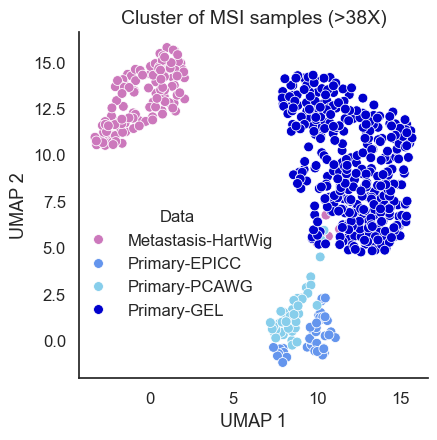

In [13]:
X = MSI_ID_norm_combined.iloc[:,:83].copy()
X = pipe.fit_transform(X.copy())
sns.set(style='white', context='notebook')
manifold = umap.UMAP(random_state=7,  n_neighbors = 30, min_dist= 0.75).fit(X)
X_reduced_4 = manifold.transform(X)

df_umap = pd.DataFrame (X_reduced_4, columns= ["UMAP 1", "UMAP 2"])
df_umap['Data'] = MSI_ID_norm_combined ['Data'].values

f, ax = plt.subplots(figsize = (4.5,4.5))
sns.scatterplot(x = "UMAP 1", y = "UMAP 2", hue = 'Data', data = df_umap, s = 50, palette = color_dict)
plt.title (f"Cluster of MSI samples (>38X)", size =14)

plt.legend(title = "Data", bbox_to_anchor = (0.6,0.33), frameon = False, fontsize = 12)
sns.despine()
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel('UMAP 1', fontsize = 13)
plt.ylabel('UMAP 2', fontsize = 13)
plt.savefig("./Figures/MILO_Fig1a.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

## Mean Indel profiles of CRC samples in each project

### GEL

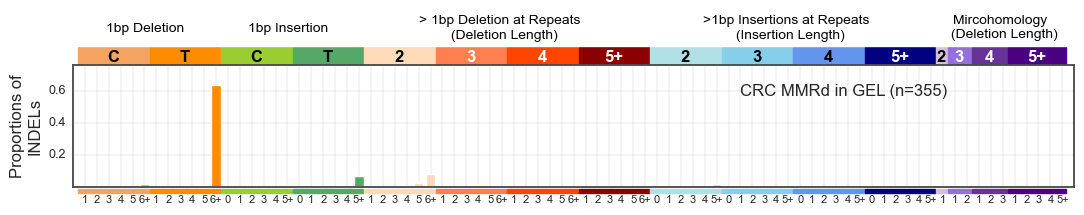

In [14]:
sample_size = df_GEL_MSI_ID_norm.shape[0]
ID83_plot(df_GEL_MSI_ID_norm.head().iloc[:, :83].mean(), norm = True, 
          name = f'CRC MMRd in GEL (n={sample_size})', 
          file = "./Figures/MILO_SFig1a.pdf")

### PCAWG

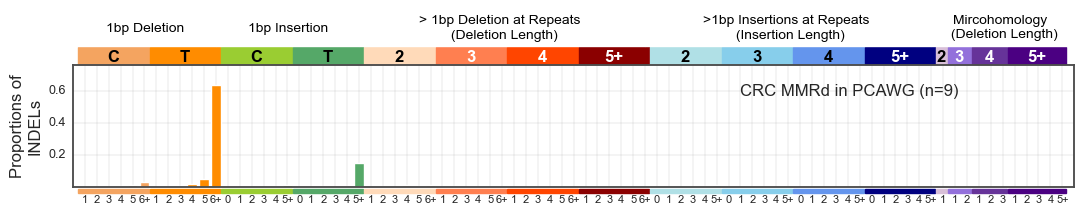

In [15]:
pcawg_crc_patients = df_PCAWG_MSI_ID_norm.index[['ColoRect' in i for i in df_PCAWG_MSI_ID_norm.index]].values

sample_size = df_PCAWG_MSI_ID_norm.loc[pcawg_crc_patients, :].shape[0]
ID83_plot(df_PCAWG_MSI_ID_norm.loc[pcawg_crc_patients, :].iloc[:,:83].mean(), 
          norm = True, 
          name = f'CRC MMRd in PCAWG (n={sample_size})',
          file = "./Figures/MILO_SFig1b.pdf")

### EPICC

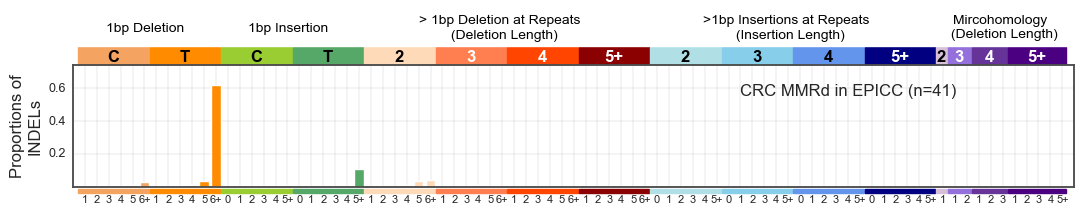

In [16]:
sample_size = df_EPICC_MSI_ID_norm.shape[0]
ID83_plot(df_EPICC_MSI_ID_norm.iloc[:,:83].mean(),
          norm = True,
          name = f'CRC MMRd in EPICC (n={sample_size})',
          file = "./Figures/MILO_SFig1c.pdf")

### Hartwig

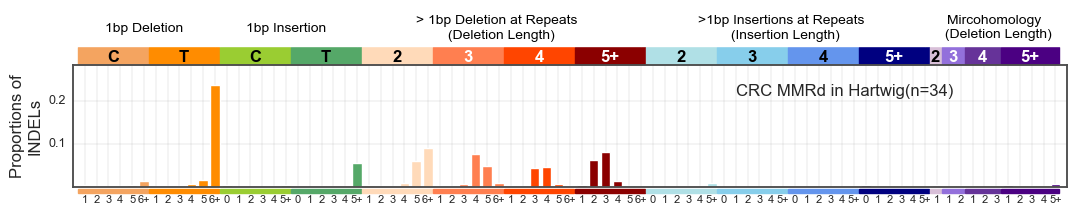

In [17]:
msi_crc_index = np.logical_and(metadata['primaryTumorLocation']=='Colon/Rectum', metadata['msStatus'] == 'MSI')
msicrc_patients_hw = list(metadata.loc[msi_crc_index, 'sampleId'].values)

crc_index = [s in msicrc_patients_hw for s in df_HW_MSI_ID_norm.index]
sample_size = np.sum(crc_index)

ID83_plot(df_HW_MSI_ID_norm.loc[crc_index, :].iloc[:,:83].mean(), norm = True,
          name = f'CRC MMRd in Hartwig(n={sample_size})', 
          file = "./Figures/MILO_SFig1d.pdf")

## MMRd-ID signature extraction

In [18]:
df_HW_MSI_ID = df_HW_MSI.iloc[:,96:179].copy()

df_PCAWG_MSI_ID = df_PCAWG.loc[df_PCAWG['MSI_status'] == 1].iloc[:,96:179].copy()

df_GEL_MSI_ID = df_GEL.loc[df_GEL['MSI_status'] == 1].iloc[:,96:179].copy()

df_EPICC_MSI_ID = df_EPICC.loc[df_EPICC['MSI_status'] == 1].iloc[:,96:179].copy()

MSI_ID_combined = pd.concat((df_HW_MSI_ID, df_EPICC_MSI_ID, df_PCAWG_MSI_ID, df_GEL_MSI_ID))
MSI_ID_combined.shape

(554, 83)

### Model seletion

In [19]:
V = MSI_ID_combined.T.copy() ## input matrix - combined cohort

nsig_opts = [2, 3, 4, 5, 6, 7, 8, 9]

pairwise_cs = [] ## reproducibility; the less, the better
matrix_distance = []

for n_sig in nsig_opts:
    
    pairwise_cs_nsig = []
    
    ## the NMF model has built in 200 iterations by default; with this many iterations 
    ## different random states generate almost the same results.
    model = NMF(n_components = n_sig, init = 'nndsvd', random_state = 123, beta_loss = 1, solver = 'mu')
        
    W_derived = model.fit_transform(V)
    H = model.components_
      
    matrix_distance.append(np.median(entropy(V, W_derived @ H)))
    #matrix_distance += list(np.log(entropy(V, W_derived @ H + 1)))
    
    V_constructed = pd.DataFrame(W_derived @ H)
    
    for i in range (V.shape[1]): 
        distance_tmp = 1 - cosine_similarity(V.iloc[:,i].to_numpy().reshape(1,83), V_constructed.iloc[:,i].to_numpy().reshape(1,83))[0][0]
        #matrix_distance.append(distance_tmp)
        
    df_tmp = pd.DataFrame(W_derived)
        
    for i in range (df_tmp.shape[1]):
        for j in range (df_tmp.shape[1]):
            if i > j:
                    
                cs_tmp = cosine_similarity (df_tmp.iloc[:,i].to_numpy().reshape(1,83), 
                                            df_tmp.iloc[:,j].to_numpy().reshape(1,83))[0][0]
                    
                pairwise_cs_nsig.append(cs_tmp)
                    
    pairwise_cs.append(pairwise_cs_nsig)

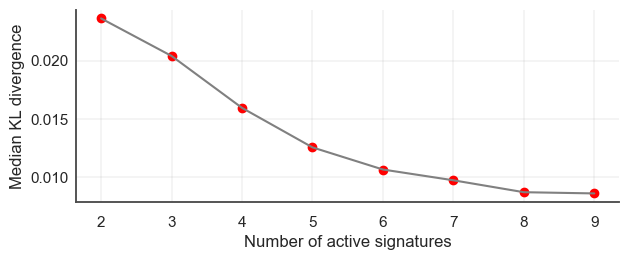

In [20]:
ax, f = plt.subplots (figsize = (7,2.5))

plt.scatter (nsig_opts, matrix_distance , color = 'red')
plt.plot (nsig_opts, matrix_distance , color = 'grey')
plt.ylabel ("Median KL divergence")
plt.xlabel ("Number of active signatures")
sns.despine ()

plt.savefig("./Figures/MILO_SFig2a.pdf", bbox_inches = "tight", dpi = 300)

plt.show()
plt.show()

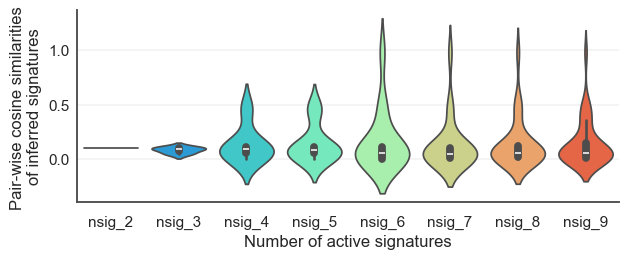

In [21]:
nsig_lists = []
pairwise_cs_list = []
for i in range(len(nsig_opts)):
    nsig_lists += ['nsig_' + str (nsig_opts[i])] * len(pairwise_cs[i])
    pairwise_cs_list += pairwise_cs[i]
    
cs_df = pd.DataFrame ({'nsig' : nsig_lists, 'cs': pairwise_cs_list})

ax, f = plt.subplots (figsize = (7,2.5))
sns.violinplot (x = 'nsig', y = 'cs', data = cs_df, palette= 'rainbow')
plt.ylabel ("Pair-wise cosine similarities \nof inferred signatures")
plt.xlabel ("Number of active signatures")
sns.despine()
plt.savefig("./Figures/MILO_SFig2b.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

### nSig = 5

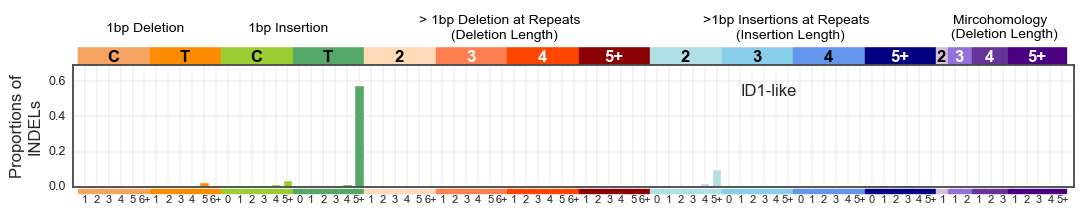

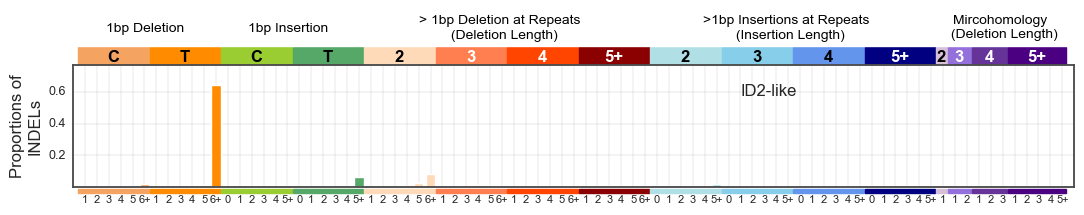

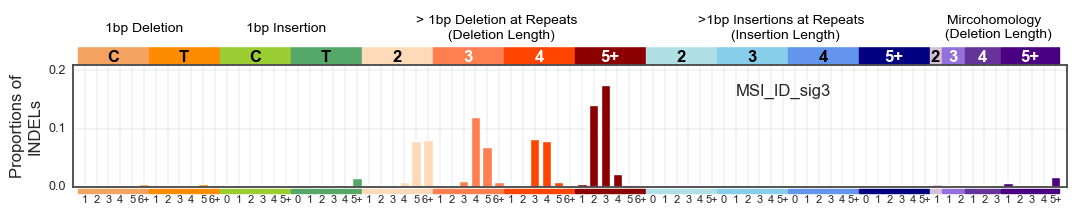

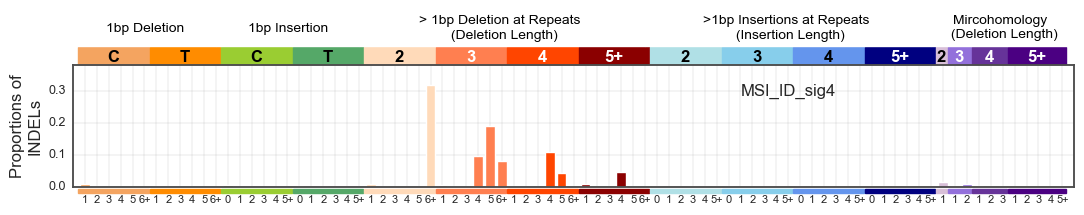

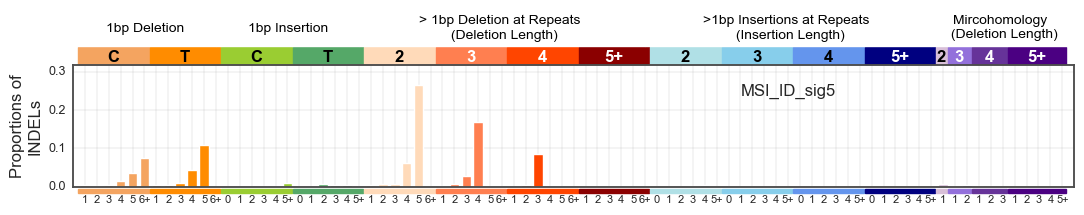

In [22]:
n_sig = 5
weights_nsig5 = []
sigs_nsig5 = []

weights_df_nsig5 = pd.DataFrame ()
inferred_id_sigs_nsig5 = pd.DataFrame ()

model = NMF(n_components = n_sig, init='nndsvd', random_state= 123, beta_loss=1, solver = 'mu')
W_derived = model.fit_transform(MSI_ID_combined.T)
H = model.components_

sig_names = ["ID2-like", "MSI_ID_sig3","ID1-like", "MSI_ID_sig4", "MSI_ID_sig5"]

for i in [2, 0, 1, 3, 4]:
    n = sig_names[i]
    weights_df_nsig5[n] = H[i]*sum(W_derived[:,i])
    inferred_id_sigs_nsig5 [n] = W_derived[:,i]/sum(W_derived[:,i])
    sigs_nsig5 += [n] * len(H[i])
    
    ID83_plot(W_derived[:,i]/sum(W_derived[:,i]), name = n, file = './Figures/MILO_Fig1b_' + n + ".pdf", norm = True)

#### Compared to known sigs

In [23]:
known_ID_sigs = pd.read_csv ("./Data/COSMIC_v3.4_ID_GRCh37.txt", sep = "\t", index_col = 0)
known_ID_sigs.head(2)

,ID1,ID2,ID3,ID4,ID5,ID6,ID7,ID8,ID9,ID10,...,ID14,ID15,ID16,ID17,ID18,ID19,ID20,ID21,ID22,ID23
Type,,,,,,,,,,,,,,,,,,,,,
1:Del:C:0,0.000160,0.004824,0.124727,0.007250,0.022202,0.030507,4.665610e-04,0.039828,0.334940,0.025105,...,0.012016,0.026527,9.527690e-04,0.006118,0.006012,0.054089,0.006578,0.001389,0.002570,0.051698
1:Del:C:1,0.000774,0.000022,0.208876,0.002735,0.028547,0.005492,1.000000e-18,0.023916,0.099994,0.029306,...,0.001946,0.121010,2.640000e-18,0.003668,0.002004,0.015009,0.003269,0.004837,0.001731,0.106194


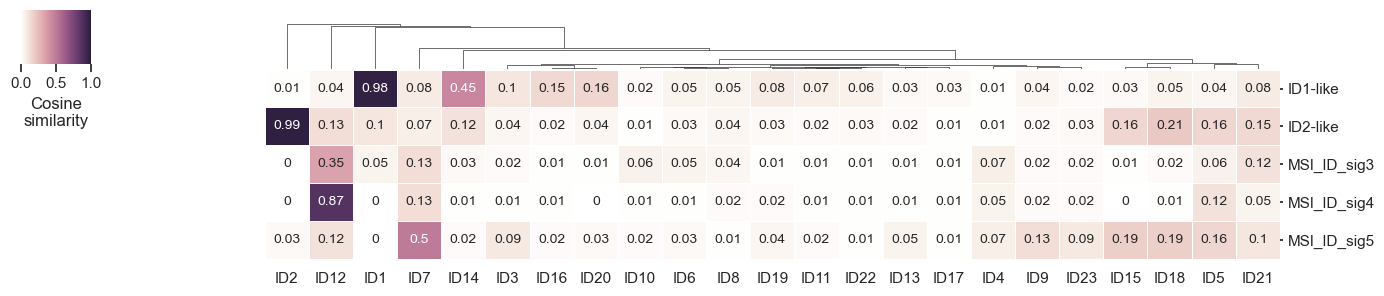

In [24]:
sim = cosine_similarity(inferred_id_sigs_nsig5.T.values, known_ID_sigs.T.values)

cmap = sns.cubehelix_palette(light=1, as_cmap=True)
result = sns.clustermap(np.round(sim, 2), linewidth = 0.5, cmap = cmap, vmin=0, vmax=1, annot = True, annot_kws={"size": 10},
                        xticklabels = known_ID_sigs.columns.values,
                        yticklabels = ['ID1-like', 'ID2-like', 'MSI_ID_sig3','MSI_ID_sig4', 'MSI_ID_sig5'],
                        figsize=(14,3), row_cluster=False,
                        cbar_kws = {'shrink': 0.5, 'ticks' : np.linspace(0,1,3),
                                   "orientation": "horizontal",
                                   'label': f"Cosine\nsimilarity"},
                                    linewidths=0.005,linecolor = "white")

plt.savefig ("./Figures/MILO_SFig3.pdf", dpi = 300, edgecolor='none')
plt.show()

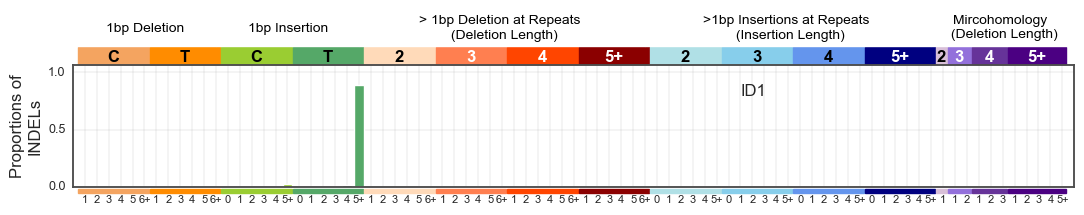

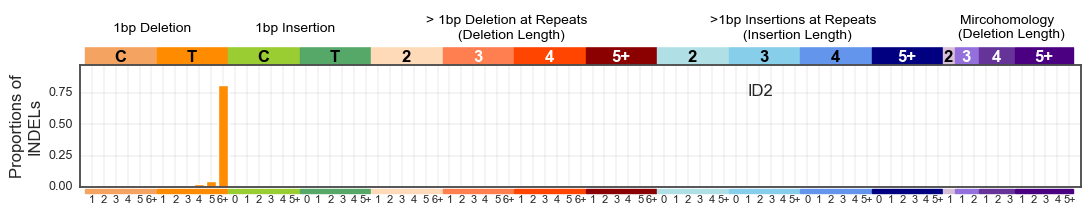

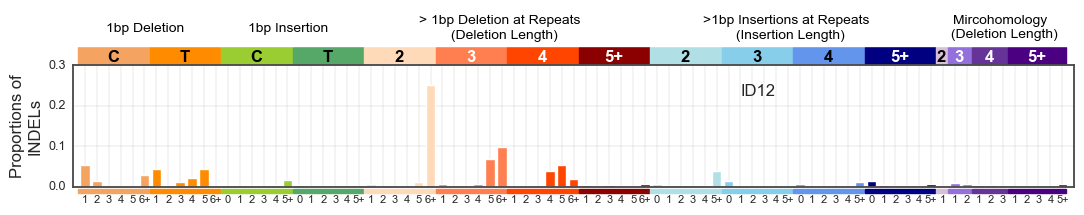

In [25]:
ID83_plot(known_ID_sigs['ID1'], name = 'ID1', norm = True)
ID83_plot(known_ID_sigs['ID2'], name = 'ID2', norm = True)
ID83_plot (known_ID_sigs ['ID12'], name = 'ID12', norm = True)

#### N5 signature activities 

In [26]:
weights_df_nsig5_norm = weights_df_nsig5.div(weights_df_nsig5.sum(axis=1), axis=0).copy()
weights_df_nsig5_norm ['samples'] =  MSI_ID_norm_combined.index
weights_df_nsig5_norm ['Data'] = list(MSI_ID_norm_combined['Data'].values)
weights_df_nsig5_norm ['stage'] =  [i.split ('-')[0] for i in list(MSI_ID_norm_combined['Data'].values)]
weights_df_nsig5_norm['Long_deletion sigs'] = weights_df_nsig5_norm.loc [:, ['MSI_ID_sig3', 
                                                                             'MSI_ID_sig4',
                                                                             'MSI_ID_sig5']].sum(axis = 1)
weights_df_nsig5_norm.head()

,ID1-like,ID2-like,MSI_ID_sig3,MSI_ID_sig4,MSI_ID_sig5,samples,Data,stage,Long_deletion sigs
0,0.091194,0.607308,0.037431,0.121995,0.142072,CPCT02010268T,Metastasis-HartWig,Metastasis,0.301498
1,0.029029,0.382718,0.424434,0.046300,0.117519,CPCT02010441T,Metastasis-HartWig,Metastasis,0.588253
2,0.113056,0.557288,0.057029,0.181606,0.091020,CPCT02010654T,Metastasis-HartWig,Metastasis,0.329656
3,0.016894,0.381081,0.451910,0.053000,0.097115,CPCT02010786T,Metastasis-HartWig,Metastasis,0.602024
4,0.000000,0.271378,0.728622,0.000000,0.000000,CPCT02010882T,Metastasis-HartWig,Metastasis,0.728622


mean contribution in primary MMRd: 0.04
mean contribution in metastasis MMRd 0.11


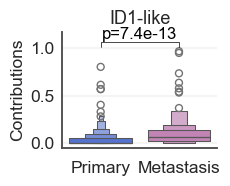

mean contribution in primary MMRd: 0.92
mean contribution in metastasis MMRd 0.47


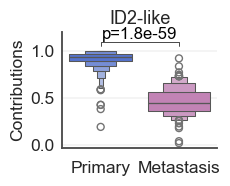

mean contribution in primary MMRd: 0.01
mean contribution in metastasis MMRd 0.22


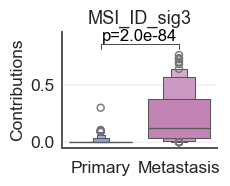

mean contribution in primary MMRd: 0.01
mean contribution in metastasis MMRd 0.12


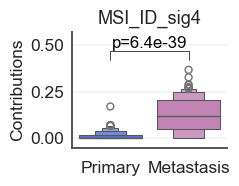

mean contribution in primary MMRd: 0.02
mean contribution in metastasis MMRd 0.07


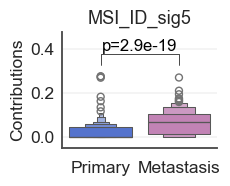

In [27]:
stage_color_dict = {'Primary' : "Royalblue", 'Metastasis' :  sns.color_palette("colorblind")[4]}
sig_names_reordered = ['ID1-like', 'ID2-like', 'MSI_ID_sig3', 'MSI_ID_sig4', 'MSI_ID_sig5']

for sig_name in sig_names_reordered:
    f, ax = plt.subplots(figsize = (2,1.5))
    sns.boxenplot(x = 'stage', y = sig_name, data = weights_df_nsig5_norm, palette = stage_color_dict, order = ['Primary', 
                                                                                                                'Metastasis'])

    x = weights_df_nsig5_norm.loc[:, ['stage', sig_name]].groupby('stage').get_group ("Primary").iloc[:, 1].values
    y = weights_df_nsig5_norm.loc[:, ['stage', sig_name]].groupby('stage').get_group ("Metastasis").iloc[:, 1].values
    
    print ("mean contribution in primary MMRd:", np.round(np.mean(x),2))
    print ("mean contribution in metastasis MMRd", np.round (np.mean(y),2))
    
    max_pos = np.max (list(x) + list(y)) + 0.05
    min_pos = np.min (list(x) + list(y)) - 0.05
    
    t, p2 = mannwhitneyu(x, y)
    
    x1, x2 =0, 1
    y, h, col = max_pos, 0.05, 'black'
    plt.ylim(0,1.1)
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.5, c = col)
    ax.text((x1+x2)*.5, y + h, 'p={0:1.1e}'.format(p2), ha='center', va='bottom', color=col)
    plt.ylim (min_pos, max_pos + 0.15)

    plt.xlabel("")
    plt.xticks(fontsize = 12.5)
    plt.yticks(fontsize = 12.5)
    plt.title (sig_name, fontsize = 13) 
    plt.ylabel("Contributions", fontsize = 12.5)
    sns.despine()
    plt.savefig("./Figures/MILO_SFig4_" + sig_name + ".pdf", bbox_inches = "tight", dpi = 300)
    plt.show()

0.04143036918809716 0.41930262503001264


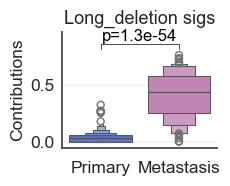

In [28]:
sig_names_reordered = ['Long_deletion sigs']
for sig_name in sig_names_reordered:
    f, ax = plt.subplots(figsize = (2,1.5))
    sns.boxenplot(x = 'stage', y = sig_name, data = weights_df_nsig5_norm, palette = stage_color_dict, order = ['Primary', 
                                                                                                                'Metastasis'])

    x = weights_df_nsig5_norm.loc[:, ['stage', sig_name]].groupby('stage').get_group ("Primary").iloc[:, 1].values
    y = weights_df_nsig5_norm.loc[:, ['stage', sig_name]].groupby('stage').get_group ("Metastasis").iloc[:, 1].values
    print (np.mean(x), np.mean(y))
    
    max_pos = np.max (list(x) + list(y)) + 0.05
    min_pos = np.min (list(x) + list(y)) - 0.05
    
    t, p2 = mannwhitneyu(x, y)
    
    x1, x2 =0, 1
    y, h, col = max_pos, 0.05, 'black'
    plt.ylim(0, 1.1)
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.5, c = col)
    ax.text((x1+x2)*.5, y + h, 'p={0:1.1e}'.format(p2), ha='center', va='bottom', color=col)
    plt.ylim (min_pos, max_pos + 0.15)

    plt.xlabel("")
    plt.xticks(fontsize = 12.5)
    plt.yticks(fontsize = 12.5)
    plt.title (sig_name, fontsize = 13) 
    plt.ylabel("Contributions", fontsize = 12.5)
    sns.despine()
    plt.savefig("./Figures/MILO_Fig1c_" + sig_name +".pdf", bbox_inches = "tight", dpi = 300)
    plt.show()

In [29]:
weights_df_nsig5_norm.loc[weights_df_nsig5_norm['stage'] == 'Metastasis','Long_deletion sigs'].std()

0.20491359351921262

In [30]:
weights_df_nsig5_norm.loc[weights_df_nsig5_norm['stage'] == 'Primary','Long_deletion sigs'].std()

0.04552630608071624

## Long deletion activities vary in organ-specific mets

In [31]:
HW_MSI_sig_weights = weights_df_nsig5_norm.loc[weights_df_nsig5_norm['Data'] == 'Metastasis-HartWig', :]
HW_MSI_sig_weights_meta = HW_MSI_sig_weights.merge(metadata, left_on = "samples", right_on = "sampleId")
HW_MSI_sig_weights_meta.head(2)

,ID1-like,ID2-like,MSI_ID_sig3,MSI_ID_sig4,MSI_ID_sig5,samples,Data,stage,Long_deletion sigs,sampleId,...,maxDiploidProportion,version,somaticPenalty,wholeGenomeDuplication,msIndelsPerMb,msStatus,tml,tmlStatus,tmbPerMb,tmbStatus
0,0.091194,0.607308,0.037431,0.121995,0.142072,CPCT02010268T,Metastasis-HartWig,Metastasis,0.301498,CPCT02010268T,...,0.0311,2.47,0.0,True,18.050717,MSI,500,HIGH,33.988807,HIGH
1,0.029029,0.382718,0.424434,0.046300,0.117519,CPCT02010441T,Metastasis-HartWig,Metastasis,0.588253,CPCT02010441T,...,0.9588,2.47,0.0,False,78.079748,MSI,962,HIGH,115.110528,HIGH


In [32]:
intresting_columns = ['primaryTumorLocation', 'biopsySite',
                      'biopsyLocation','hasSystemicPreTreatment', 'hasRadiotherapyPreTreatment',
                    'treatmentGiven',  'treatment','treatmentType', 'responseMeasured', 'firstResponse', 
                      'birthYear', 'biopsyDate', 'deathDate', 'treatmentStartDate', 'treatmentEndDate','responseDate' ]

In [33]:
primaryTumourLocation_summary_df = HW_MSI_sig_weights_meta.groupby('primaryTumorLocation').describe()
ranked_organs_with_proper_sample_size = (primaryTumourLocation_summary_df['Long_deletion sigs']).sort_values (['count'], 
                                        ascending = False).iloc[:7,:].sort_values (['mean'], ascending = False ).index.values

In [34]:
(primaryTumourLocation_summary_df['Long_deletion sigs']).sort_values (['count'],                                
                    ascending = False).iloc[:7,:].sort_values (['mean'], ascending = False)

,count,mean,std,min,25%,50%,75%,max
primaryTumorLocation,,,,,,,,
Colon/Rectum,34.0,0.583754,0.149722,0.007896,0.557838,0.603636,0.678386,0.766510
Breast,10.0,0.397664,0.142141,0.076675,0.334311,0.422129,0.483166,0.577555
Urinary tract,5.0,0.376695,0.238721,0.116708,0.116766,0.517605,0.542569,0.589826
Lung,5.0,0.364560,0.139442,0.172757,0.266733,0.427339,0.448444,0.507530
Uterus,8.0,0.350783,0.154047,0.154447,0.186105,0.397151,0.456808,0.540434
Prostate,27.0,0.318292,0.139401,0.037013,0.217893,0.313700,0.431482,0.547096
Nervous system,6.0,0.074843,0.076973,0.004548,0.013924,0.049215,0.132290,0.183941


In [35]:
primary_organ_plot_df = HW_MSI_sig_weights_meta.loc[[pt in ranked_organs_with_proper_sample_size 
                                                     for pt in HW_MSI_sig_weights_meta['primaryTumorLocation'].values],
                                                    ['primaryTumorLocation', 'Long_deletion sigs']].copy()

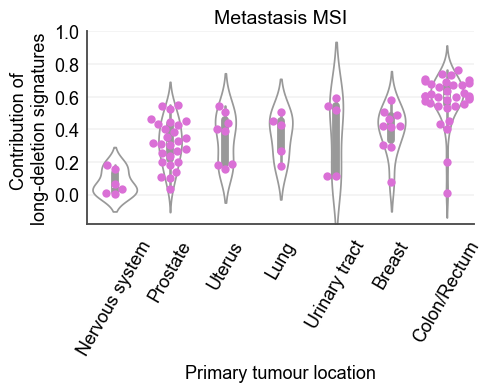

In [36]:
ax, f = plt.subplots(figsize = (5,2.5))
sns.violinplot(x = 'primaryTumorLocation', y = 'Long_deletion sigs', data = primary_organ_plot_df,
               order = ranked_organs_with_proper_sample_size[::-1], color = "white")
sns.swarmplot(x = 'primaryTumorLocation', y = 'Long_deletion sigs', data = primary_organ_plot_df, 
              order = ranked_organs_with_proper_sample_size[::-1],  color = '#DA70D6', s = 6) #'orchid')
plt.xlabel("Primary tumour location", fontsize = 13, color = "black")
plt.ylabel("Contribution of \nlong-deletion signatures", fontsize = 13, color = "black")
plt.xticks(size = 13, rotation = 60, color = "black")
plt.yticks(size = 13,color = "black")

plt.ylim(-0.18,1)
plt.title("Metastasis MSI", fontsize = 14, color = "black")
sns.despine()
plt.savefig("./Figures/MILO_Fig1d.pdf",  bbox_inches = "tight", dpi = 300)
plt.show()

In [37]:
outliers = [ 'CPCT02380016T', 'WIDE01010470T']
weights_df_nsig5_norm.loc [weights_df_nsig5_norm['samples'] == outliers[0], :]

,ID1-like,ID2-like,MSI_ID_sig3,MSI_ID_sig4,MSI_ID_sig5,samples,Data,stage,Long_deletion sigs
59,0.151753,0.64643,0.000209,0.096165,0.105443,CPCT02380016T,Metastasis-HartWig,Metastasis,0.201817


In [38]:
weights_df_nsig5_norm.loc [weights_df_nsig5_norm['samples'] == outliers[1], :]

,ID1-like,ID2-like,MSI_ID_sig3,MSI_ID_sig4,MSI_ID_sig5,samples,Data,stage,Long_deletion sigs
111,0.578135,0.413969,0.0,0.0,0.007896,WIDE01010470T,Metastasis-HartWig,Metastasis,0.007896


In [39]:
df_HW_MSI_ID.loc[crc_index, :].iloc[:,:83].sum(axis = 1).sort_values().head()

CPCT02380016T    19540
WIDE01010470T    30031
CPCT02080048T    52495
CPCT02250005T    76053
DRUP01010211T    87350
dtype: int64

In [40]:
np.median (df_HW_MSI_ID.loc[crc_index, :].iloc[:,:83].sum(axis = 1))

340289.0

## Long deletion signature activities correlates with total Indel count

Colon/Rectum 	 SignificanceResult(statistic=0.6122230710466005, pvalue=0.00011909742721233651)
Prostate 	 SignificanceResult(statistic=0.8492063492063492, pvalue=2.1413794812065693e-08)


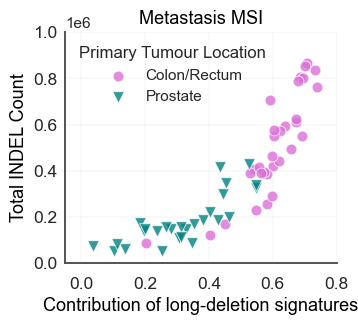

In [41]:
sns.set(style="whitegrid", color_codes=True, rc={"grid.linewidth": 0.1, 'grid.color': '.7', 
                                                     'ytick.major.size': 2,'axes.edgecolor': '.3',
                                                     'axes.linewidth': 1.35,"figure.figsize":(3.5, 3)})
a = [1,0.7]
s = [ 'o', 'v']
c = [ 'Orchid','Teal']
ec = ['w', 'black']
ss = [60, 70]
for i, organ in enumerate(['Colon/Rectum', 'Prostate']):
    df_tmp = HW_MSI_sig_weights_meta.groupby('primaryTumorLocation').get_group (organ)
    target_samples = df_tmp['samples'].values
    total_count = df_HW_MSI.loc[target_samples, :].sum(axis = 1)
    
    long_del_sigs = []
    for sample in target_samples:
        long_del_sigs.append(HW_MSI_sig_weights_meta['Long_deletion sigs'].values[HW_MSI_sig_weights_meta['samples']== sample][0])
        
    df_tmp2 = pd.DataFrame({'contribution' : long_del_sigs, 'count' : total_count})
    print (organ, "\t", stats.spearmanr(df_tmp2['contribution'], df_tmp2['count']))
    sns.scatterplot(x= 'contribution', y= 'count', data = df_tmp2, color = c[i], 
                     marker = s[i], s = ss [i], label = organ, alpha = .8)

    sns.despine()
    plt.xlim (-0.05, 0.8)
    
plt.xlabel("Contribution of long-deletion signatures", color = 'black', size = 13)
plt.ylabel("Total INDEL Count", color = 'black', size = 13)
plt.legend(frameon = False, title = "Primary Tumour Location")
plt.ylim (0, 1000000)
plt.title ("Metastasis MSI",color = 'black', size = 13)
plt.xticks(fontsize = 12.5)
plt.yticks(fontsize = 12.5)
plt.savefig("./Figures/MILO_Fig1e.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

In [42]:
print (stats.spearmanr(df_tmp2['contribution'], df_tmp2['count']))

SignificanceResult(statistic=0.8492063492063492, pvalue=2.1413794812065693e-08)


# Comparison of indel mutation count between primary vs metastasis CRCs 

## Total indel number

In [43]:
items = ['1_Del_T', '2_Del_R', '3_Del_R', '4_Del_R', '5_Del_R']

## Hartwig
crc_hw_patients = HW_MSI_sig_weights_meta.loc[[pt == 'Colon/Rectum' for pt in HW_MSI_sig_weights_meta['primaryTumorLocation'].values],:]['samples']

df_tmp = pd.DataFrame({'sample' : crc_hw_patients,
                      '1_Del_T' : [0] * len(crc_hw_patients), 
                       '2_Del_R':[0] * len(crc_hw_patients),
                       '3_Del_R' : [0] * len(crc_hw_patients), 
                       '4_Del_R' : [0] * len(crc_hw_patients),
                       '5_Del_R' : [0] * len(crc_hw_patients)})

col = color_dict.get('Metastasis-HartWig')

for p in crc_hw_patients:
    for i in items:
        value = df_HW_MSI_ID.loc[p, [i in c for c in df_HW_MSI_ID.columns]].sum()
        df_tmp.loc[df_tmp['sample']== p, i] = value

## GEL
col = color_dict.get ("Primary-GEL")

df_tmp1 = pd.DataFrame({'sample' : df_GEL_MSI_ID.index.values,
                        '1_Del_T' : [0] * len(df_GEL_MSI_ID.index.values), 
                       '2_Del_R': [0] * len(df_GEL_MSI_ID.index.values),
                       '3_Del_R' : [0] * len(df_GEL_MSI_ID.index.values), 
                       '4_Del_R' : [0] * len(df_GEL_MSI_ID.index.values),
                       '5_Del_R' : [0] * len(df_GEL_MSI_ID.index.values)})
    
for p in df_GEL_MSI_ID.index.values:
    for i in items:
        value = df_GEL_MSI_ID.loc[p, [i in c for c in df_GEL_MSI_ID.columns]].sum()
        df_tmp1.loc[df_tmp1['sample']== p, i] = value
    

In [44]:
combined_hw_gel_abs_data = pd.concat((df_tmp1,df_tmp))
combined_hw_gel_abs_data['data'] =  ['Primary_GEL']* df_tmp1.shape[0] + ['Metastasis_Hartwig'] * df_tmp.shape[0]
combined_hw_gel_abs_data['Total'] = combined_hw_gel_abs_data.iloc[:, 1:6].sum(axis = 1)
combined_hw_gel_abs_data['weighted_Total'] = (combined_hw_gel_abs_data.iloc[:, 1:6] * np.array([1,2,3,4,5])).sum(axis = 1)

combined_hw_gel_abs_data.head(2)

,sample,1_Del_T,2_Del_R,3_Del_R,4_Del_R,5_Del_R,data,Total,weighted_Total
0,sample7,217209,28075,4176,3134,3093,Primary_GEL,255687,313888
1,sample10,257847,66334,25518,15761,22021,Primary_GEL,387481,640218


In [45]:
melted_combined_hw_gel_abs_data = pd.melt (combined_hw_gel_abs_data, id_vars = ["data"])

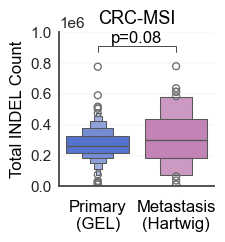

In [46]:
ax, f = plt.subplots(figsize = (2,2))

ax = sns.boxenplot(x = 'data', y = 'value', data = melted_combined_hw_gel_abs_data.loc[melted_combined_hw_gel_abs_data['variable'] == 'Total',:], 
             palette= {'Primary_GEL': 'Royalblue', 'Metastasis_Hartwig': (0.8, 0.47058823529411764, 0.7372549019607844)})
sns.despine()
x = combined_hw_gel_abs_data.loc[combined_hw_gel_abs_data['data'] == 'Metastasis_Hartwig', 'Total' ].values
y = combined_hw_gel_abs_data.loc[combined_hw_gel_abs_data['data'] == 'Primary_GEL', 'Total' ].values

t, p2 = mannwhitneyu(x, y)
    
x1, x2 =0, 1
y, h, col = 0.87*10**6, 40000, 'black'
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.5, c = col)
ax.text((x1+x2)*.5, y + h + 0.1, 'p={0:.2f}'.format(p2), ha='center', va='bottom', color=col)

plt.ylabel('Total INDEL Count',fontsize = 12, color = "black")
plt.ylim (0,10**6)
plt.xlabel ('')
plt.title("CRC-MSI", fontsize = 13, color = "black")
plt.xticks(range (2), ['Primary\n(GEL)', 'Metastasis\n(Hartwig)'], rotation = 0, fontsize = 12, color = "black")
plt.savefig ("./Figures/MILO_Fig1f.pdf",  bbox_inches = "tight", dpi = 300)
plt.show()

## Total number of slippage events

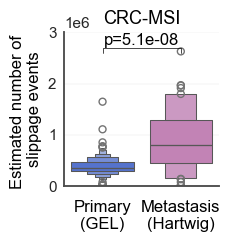

In [47]:
ax, f = plt.subplots(figsize = (2,2))

ax = sns.boxenplot(x = 'data', y = 'value', 
              data = melted_combined_hw_gel_abs_data.loc[melted_combined_hw_gel_abs_data['variable'] == 'weighted_Total',:], 
             palette= {'Primary_GEL': 'Royalblue', 'Metastasis_Hartwig': (0.8, 0.47058823529411764, 0.7372549019607844)})

x = combined_hw_gel_abs_data.loc[combined_hw_gel_abs_data['data'] == 'Metastasis_Hartwig', 'weighted_Total' ].values
y = combined_hw_gel_abs_data.loc[combined_hw_gel_abs_data['data'] == 'Primary_GEL', 'weighted_Total' ].values

t, p2 = mannwhitneyu(x, y)
    
x1, x2 =0, 1
y, h, col = 2.6*10**6, 100000, 'black'
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.5, c = col)
ax.text((x1+x2)*.5, y + h + 0.1, 'p={0:1.1e}'.format(p2), ha='center', va='bottom', color=col)

sns.despine()
plt.ylim (0,3*10**6)
plt.ylabel('Estimated number of \nslippage events',fontsize = 12, color = "black")
plt.xlabel ('')
plt.title("CRC-MSI", fontsize = 13, color = "black")
plt.xticks(range (2), ['Primary\n(GEL)', 'Metastasis\n(Hartwig)'], rotation = 0, fontsize = 12, color = "black")
plt.savefig ("./Figures/MILO_Fig2g.pdf",  bbox_inches = "tight", dpi = 300)
plt.show()

## Absolute indel count at different lengths

In [48]:
print ('P_value of comparison between primary to metastasis CRC samples')
for col in ['Total', '1_Del_T', '2_Del_R', '3_Del_R', '4_Del_R', '5_Del_R']:
    x = combined_hw_gel_abs_data.loc[combined_hw_gel_abs_data['data'] == 'Metastasis_Hartwig', col ].values
    y = combined_hw_gel_abs_data.loc[combined_hw_gel_abs_data['data'] == 'Primary_GEL', col ].values

    t, p2 = mannwhitneyu(x, y)
    print (col, p2,  " = ", 'p={0:1.1e}'.format(p2), p2 < 0.05)

P_value of comparison between primary to metastasis CRC samples
Total 0.07863023607522304  =  p=7.9e-02 False
1_Del_T 1.2402196970290675e-18  =  p=1.2e-18 True
2_Del_R 1.5738523866048845e-05  =  p=1.6e-05 True
3_Del_R 5.710776239190121e-14  =  p=5.7e-14 True
4_Del_R 9.984701934487912e-14  =  p=1.0e-13 True
5_Del_R 2.732022252802666e-13  =  p=2.7e-13 True


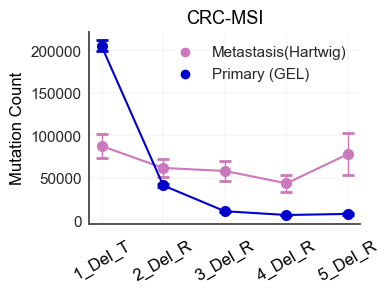

In [49]:
ax, f = plt.subplots(figsize = (3.5,2.5))

color_dict = {"Metastasis-HartWig": sns.color_palette("colorblind")[4], 
              "Primary-PCAWG": 'Skyblue', 
              "Primary-EPICC": 'Cornflowerblue',
              "Primary-GEL" : 'Mediumblue'}
## Hartwig
df_tmp = pd.DataFrame({'sample' : crc_hw_patients,
                      '1_Del_T' : [0] * len(crc_hw_patients), 
                       '2_Del_R':[0] * len(crc_hw_patients),
                       '3_Del_R' : [0] * len(crc_hw_patients), 
                       '4_Del_R' : [0] * len(crc_hw_patients),
                       '5_Del_R' : [0] * len(crc_hw_patients)})

col = color_dict.get('Metastasis-HartWig')
for p in crc_hw_patients:
    for i in items:
        value = df_HW_MSI_ID.loc[p, [i in c for c in df_HW_MSI_ID.columns]].sum()
        df_tmp.loc[df_tmp['sample']== p, i] = value

for c in df_tmp.columns[1:]:
    df_tmp[c +"_log"] = (df_tmp[c])
    
plt.plot(df_tmp.iloc[:, 6:].mean(), color = col)
plt.scatter (range(5), df_tmp.iloc[:, 6:].mean(), color = col, label = 'Metastasis(Hartwig)')

level_higher_limits = df_tmp.iloc[:, 6:].apply(lambda x: CI(x)[0])
level_lower_limits = df_tmp.iloc[:, 6:].apply(lambda x: CI(x)[1])

level_lower_limits = df_tmp.iloc[:, 6:].apply(lambda x: CI(x)[0])
level_higher_limits = df_tmp.iloc[:, 6:].apply(lambda x: CI(x)[1])

plt.errorbar(range(5), df_tmp.iloc[:, 6:].mean(), 
             yerr = [df_tmp.iloc[:, 6:].mean() - level_lower_limits, level_higher_limits - df_tmp.iloc[:, 6:].mean()], 
             fmt = "o", capsize=4, elinewidth = 1, markeredgewidth = 2, color = col)

## GEL


col = color_dict.get ("Primary-GEL")

df_tmp = pd.DataFrame({'sample' : df_GEL_MSI_ID.index.values,
                        '1_Del_T' : [0] * len(df_GEL_MSI_ID.index.values), 
                       '2_Del_R':[0] * len(df_GEL_MSI_ID.index.values),
                       '3_Del_R' : [0] * len(df_GEL_MSI_ID.index.values), 
                       '4_Del_R' : [0] * len(df_GEL_MSI_ID.index.values),
                       '5_Del_R' : [0] * len(df_GEL_MSI_ID.index.values)})
    
for p in df_GEL_MSI_ID.index.values:
    for i in items:
        value = df_GEL_MSI_ID.loc[p, [i in c for c in df_GEL_MSI_ID.columns]].sum()
        df_tmp.loc[df_tmp['sample']== p, i] = value

for c in df_tmp.columns[1:]:
    df_tmp[c +"_log"] = (df_tmp[c])
    
plt.plot(df_tmp.iloc[:, 6:].mean(), color = col)
plt.scatter (range(5), df_tmp.iloc[:, 6:].mean(), color = col, label = 'Primary (GEL)')
#error = np.std(df_tmp.iloc[:, 6:])
level_lower_limits = df_tmp.iloc[:, 6:].apply(lambda x: CI(x)[0])
level_higher_limits = df_tmp.iloc[:, 6:].apply(lambda x: CI(x)[1])

plt.errorbar(range(5), df_tmp.iloc[:, 6:].mean(), 
             yerr = [df_tmp.iloc[:, 6:].mean() - level_lower_limits, level_higher_limits - df_tmp.iloc[:, 6:].mean()], 
             fmt = "o", capsize=4, elinewidth = 1, markeredgewidth = 2, color = col)
sns.despine()
plt.xticks(range(5), items, rotation = 30, fontsize = 12, color = "black")
plt.legend(loc = "upper right", frameon = False)
plt.ylabel("Mutation Count",  fontsize = 12, color = "black")
plt.title ("CRC-MSI", fontsize = 13, color = "black")
plt.savefig ("./Figures/MILO_Fig1g.pdf",  bbox_inches = "tight", dpi = 300)

plt.show()

# Accumulation patterns of Indels in old and young biopsies

## MSH6 gene KO (knockouts)

In [50]:
MSH6_KO_df = pd.read_csv ("./Data/MSH6_KO_profile.csv", index_col = 0)

MSH6_ko_days = {"MSH6_3_s4_ko" : "15_days", "MSH6_4_s2_ko" : "15_days", 
                "MSH6_3_s5_ko" : "30_days", "MSH6_4_s3_ko" : "30_days",
                "MSH6_3_s6_ko" : "45_days", "MSH6_3_s8_ko" : "45_days",
                "MSH6_4_s4_ko" : "45_days", "MSH6_4_s7_ko" : "45_days"}

MSH6_KO_df ['days'] = [MSH6_ko_days.get (i) for i in MSH6_KO_df.index]
MSH6_KO_df.head(2)

,C2A_ACA,C2A_ACC,C2A_ACG,C2A_ACT,C2A_CCA,C2A_CCC,C2A_CCG,C2A_CCT,C2A_GCA,C2A_GCC,...,5_Del_M_5,ko_gene,subgroups,MSI_status,days,1bp_ID::HP_T,2bp_Del::Rep,3bp_Del::Rep,4bp_Del::Rep,5+bp_Del::Rep
MSH6_3_s4_ko,6,9,0,13,35,44,11,166,42,12,...,0,MSH6,MSH6,1,15_days,555,0.0,0.0,0.0,0.0
MSH6_3_s5_ko,8,5,2,29,32,68,12,192,40,14,...,1,MSH6,MSH6,1,30_days,683,0.0,0.0,0.0,0.0


### Absolute mutation count in biospies collected at different times

In [51]:
one_bp_indels = ['1_Del_T_5', '1_Ins_T_5']
items = ['1_ID_T_5', '2_Del_R', '3_Del_R', '4_Del_R', '5_Del_R']
items_label = ['1bp_ID::HP_T', '2bp_Del::Rep', '3bp_Del::Rep', '4bp_Del::Rep', '5+bp_Del::Rep']

MSH6_KO_df[items_label[0]] = MSH6_KO_df.loc[:, one_bp_indels].sum(axis = 1)
for i, ite in enumerate(items_label[1:]):
    MSH6_KO_df [items_label[i+1]] = MSH6_KO_df.loc[:, [ite in c for c in MSH6_KO_df.columns]].sum(axis = 1)

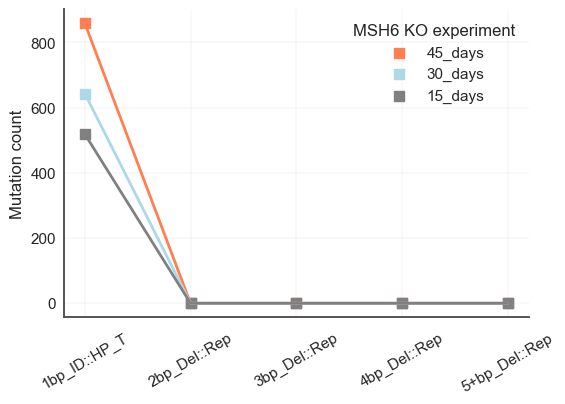

In [52]:
f, ax = plt.subplots(figsize = (6,4))
MSH6_col = {"15_days": "grey", "30_days" : "lightblue" , "45_days" : "coral"}
patient_df = MSH6_KO_df.iloc[:,182:].melt(id_vars = ['days'])

if len(patient_df['days'].unique()) != 1:
    for l in ["45_days",  "30_days", "15_days"]:
        tmp1 = patient_df.groupby(["days"]).get_group ((l)).iloc[:,1:].groupby("variable").mean()
        plt.plot(items_label, tmp1,
                     color =  MSH6_col.get (l), linewidth = 2)
        plt.scatter(items_label,tmp1, s = 50, 
                        color = MSH6_col.get (l), marker = ",",
                        label = l)
    
plt.legend (frameon = False, title = "MSH6 KO experiment")
plt.xticks (rotation = 30 )
plt.xlabel("")
plt.ylabel("Mutation count")
plt.savefig("./Figures/MILO_Sfig7.pdf", bbox_inches = "tight", dpi = 300)
sns.despine()
plt.show()

### Indel accumulation patterns between young and old biospies

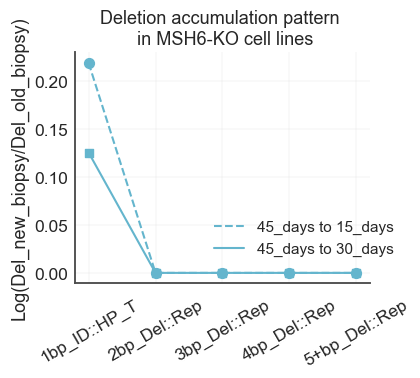

In [53]:
patient_df = MSH6_KO_df.iloc[:,182:].melt(id_vars = ['days'])
ax, fig = plt.subplots(figsize = (3.8,3))

if len(patient_df['days'].unique()) != 1:
    l = "15_days"
    tmp1 = patient_df.groupby(["days"]).get_group ((l)).iloc[:,1:].groupby("variable").mean()
    values1 = tmp1['value'].values
    
    l = "45_days"
    tmp2 = patient_df.groupby(["days"]).get_group ((l)).iloc[:,1:].groupby("variable").mean()
    values2 = tmp2['value'].values
    
    plt.plot(items_label, np.log10((values2+ 0.000001)/(values1 + 0.000001)), linestyle= '--', 
         color = 'c', label = "45_days to 15_days")
    plt.scatter(items_label, np.log10((values2+ 0.000001)/(values1 + 0.000001)), s = 50, color = 'c')

    l = "30_days"
    tmp1 = patient_df.groupby(["days"]).get_group ((l)).iloc[:,1:].groupby("variable").mean()
    values1 = tmp1['value'].values
    
    plt.plot(items_label, np.log10((values2+ 0.000001)/(values1 + 0.000001)), 
         color = 'c', label = "45_days to 30_days")
    plt.scatter(items_label, np.log10((values2+ 0.000001)/(values1 + 0.000001)), s = 30, color = 'c', marker = ',')

plt.legend (title = "MSH6 KO experiment", frameon = False)
plt.xticks (rotation = 30, fontsize = 12.5)
plt.yticks (fontsize = 12.5)
plt.xlabel("")
sns.despine()
plt.ylabel ("Log(Del_new_biopsy/Del_old_biopsy)", fontsize =13)
plt.title('Deletion accumulation pattern \n in MSH6-KO cell lines', size = 13)
plt.legend(loc = (0.45, 0.09), frameon = False)
plt.savefig("./Figures/MILO_Fig2h.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

## Indel accumulation patter in primary MMRd tumours

The samples are from EPICC cohort. Here, 'carcinomas' are reletively older tumours comparing to 'adenoma'/'normal' samples.

### Comparison of absolute indel number

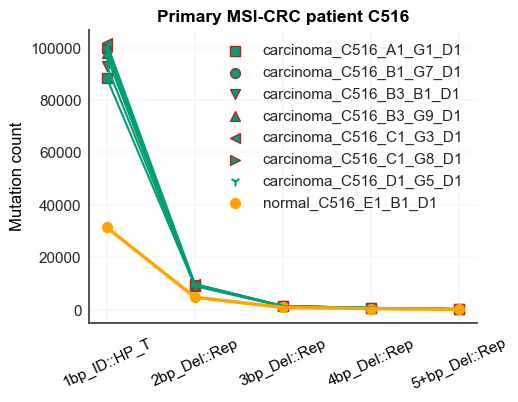

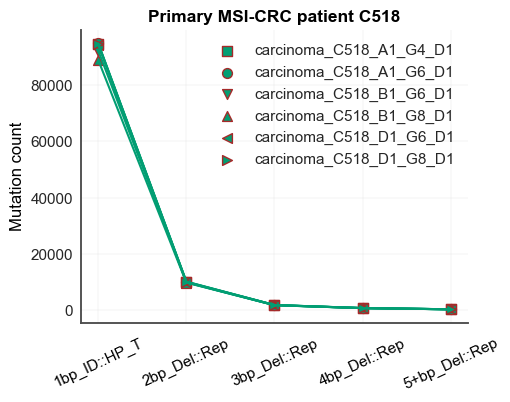

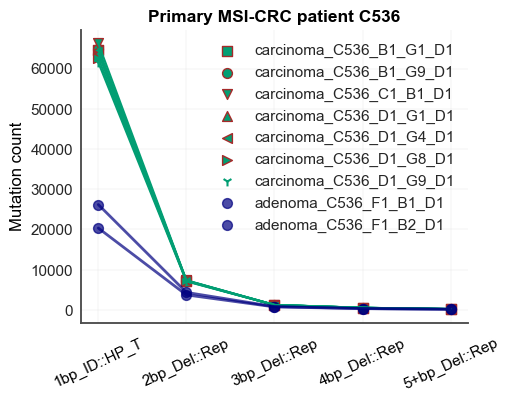

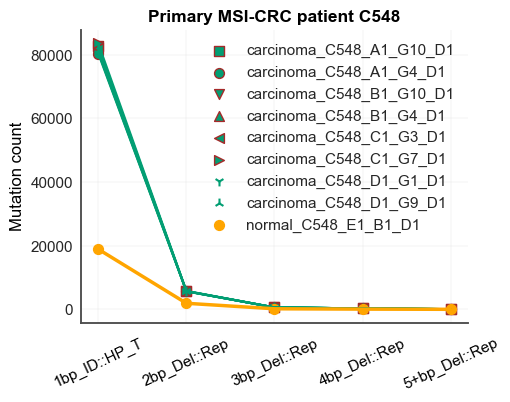

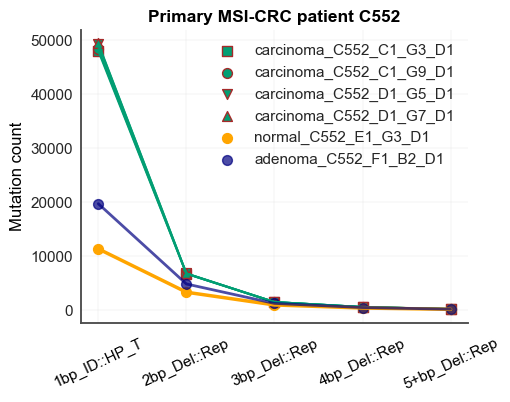

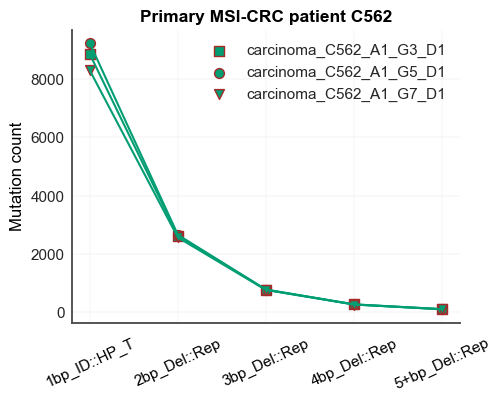

In [54]:
df_EPICC_MSI_ID['Patient'] = [s.split("_")[1] for s in df_EPICC_MSI_ID.index]

barcode_dict = {b : "carcinoma" for b in ['A', 'B', 'C', 'D']}
barcode_dict['F'] = "adenoma"
barcode_dict['G'] = "adenoma"
barcode_dict['E'] = "normal"

color_dict = {"carcinoma": sns.color_palette("colorblind")[2], "adenoma" : "#000080", "advanced_adenoma" : "#00FFFF",
              "normal" : "#FFA500"}

markers = list(Line2D.markers.keys())

for ci1, patient in enumerate (df_EPICC_MSI_ID['Patient'].unique()):
    ax, fig = plt.subplots(figsize = (5,3.8))
    
    marker_ind = 0
    for ci, s in enumerate (df_EPICC_MSI_ID.loc[df_EPICC_MSI_ID['Patient'] == patient,:].index.values):
        
        sample_bc = s.split("_")[2][0]
        
        values1 = []
        
        values1.append(df_EPICC_MSI_ID.loc[s, one_bp_indels].sum())
        
        for i in items[1:]:   
            values1.append (df_EPICC_MSI_ID.loc[s, [i in c for c in df_EPICC_MSI_ID.columns]].sum())
        
        if barcode_dict.get(sample_bc) == "carcinoma":
            marker_ind += 1
            plt.plot(items_label, values1, color = color_dict.get ("carcinoma"))
            #plt.scatter(items, values1, color = sns.color_palette("Paired")[0], label = "Biopsy A in bone \n(10 months earlier)" )
            plt.scatter(items_label, values1, color = color_dict.get ("carcinoma"), marker = markers[marker_ind], 
                        label = barcode_dict.get(sample_bc,'unclassified') + "_"+ s[6:], s = 50, edgecolor = "brown")
            
        if barcode_dict.get(sample_bc) == "adenoma":
            plt.plot(items_label, values1, color = color_dict.get ("adenoma") , alpha = .7, linewidth = 2)
            plt.scatter(items_label, values1, color = color_dict.get ("adenoma"), alpha = .7,s = 50,
                        label = barcode_dict.get(sample_bc,'unclassified') + "_"+ s[6:])
            
        if barcode_dict.get(sample_bc) == "normal":
            plt.plot(items_label, values1, color = color_dict.get ("normal"), linewidth = 2.5)
            plt.scatter(items_label, values1, color = color_dict.get ("normal"), s = 50,
                        label = barcode_dict.get(sample_bc,'unclassified') + "_"+ s[6:])
            
    plt.xticks(rotation = 25, fontsize = 11, color = "black")        
    plt.title("Primary MSI-CRC patient " + patient, fontsize = 12.5, color = "black", weight = "bold")
    plt.legend(frameon= False)
    plt.ylabel("Mutation count", fontsize = 12, color = "black")
    sns.despine()
    plt.savefig("./Figures/MILO_SFig8" + patient + ".pdf", bbox_inches = "tight", dpi = 300 )
    plt.show()

### Accumulation pattern in primary MMRd cancers

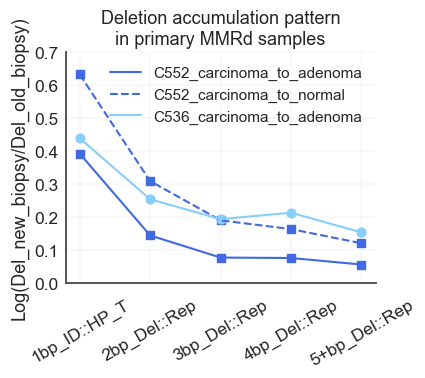

In [55]:
marker_ind = 0
stage_color_dict = {'Primary' : "Royalblue", 'Metastasis' :  sns.color_palette("colorblind")[4]}

ax, fig = plt.subplots(figsize = (4,3))

#for patient in df_epicc_t_MSI_paper['Patient'].unique():
for patient in ['C552']:    
    ID_length = []
    mut_count = []
    group = []

    for s in  df_EPICC_MSI_ID.loc[df_EPICC_MSI_ID['Patient'] == patient,:].index.values:
        sample_bc = s.split("_")[2][0]
    
        ID_length += items_label
    
        mut_count.append(df_EPICC_MSI_ID.loc[s, one_bp_indels].sum())
        group.append(barcode_dict.get(sample_bc,'unclassified'))
    
        for i in items[1:]:
            group.append(barcode_dict.get(sample_bc,'unclassified'))
            mut_count.append (df_EPICC_MSI_ID.loc[s, [i in c for c in df_EPICC_MSI_ID.columns]].sum())
        
    patient_df = pd.DataFrame({"ID_length" : ID_length, "Count" : mut_count, "Group": group})
    
    if len(patient_df['Group'].unique()) != 1:
        marker_ind += 1
        tmp1 = patient_df.groupby(["Group"]).get_group (("carcinoma")).iloc[:,:2].groupby("ID_length").mean()
        
        if "adenoma" in patient_df['Group'].unique():
            tmp2 = patient_df.groupby(["Group"]).get_group (("adenoma")).iloc[:,:2].groupby("ID_length").mean()
            plt.plot(items_label, np.log10(tmp1['Count']/(tmp2['Count'] + 0.000001)),
                     color = stage_color_dict.get('Primary'),  label = patient + "_carcinoma_to_adenoma")
            
            plt.scatter(items_label, np.log10(tmp1['Count']/(tmp2['Count'] + 0.000001)), s = 40, 
                        marker = markers [marker_ind], color = stage_color_dict.get('Primary'))
            
        if "normal" in patient_df['Group'].unique():
            tmp3 = patient_df.groupby(["Group"]).get_group (("normal")).iloc[:,:2].groupby("ID_length").mean()
            plt.plot(items_label, np.log10(tmp1['Count']/(tmp3['Count'] + 0.000001)), linestyle= '--', 
                     color = stage_color_dict.get("Primary"), label = patient + "_carcinoma_to_normal")
            plt.scatter(items_label, np.log10(tmp1['Count']/(tmp3['Count'] + 0.000001)), s = 40,
            color = stage_color_dict.get("Primary"), marker = markers [marker_ind])

for patient in ['C536']:    
    ID_length = []
    mut_count = []
    group = []

    for s in  df_EPICC_MSI_ID.loc[df_EPICC_MSI_ID['Patient'] == patient,:].index.values:
        sample_bc = s.split("_")[2][0]
    
        ID_length += items_label
    
        mut_count.append(df_EPICC_MSI_ID.loc[s, one_bp_indels].sum())
        group.append(barcode_dict.get(sample_bc,'unclassified'))
    
        for i in items[1:]:
            group.append(barcode_dict.get(sample_bc,'unclassified'))
            mut_count.append (df_EPICC_MSI_ID.loc[s, [i in c for c in df_EPICC_MSI_ID.columns]].sum())
        
    patient_df = pd.DataFrame({"ID_length" : ID_length, "Count" : mut_count, "Group": group})
    
    if len(patient_df['Group'].unique()) != 1:
        marker_ind += 1
        tmp1 = patient_df.groupby(["Group"]).get_group (("carcinoma")).iloc[:,:2].groupby("ID_length").mean()
        
        if "adenoma" in patient_df['Group'].unique():
            tmp2 = patient_df.groupby(["Group"]).get_group (("adenoma")).iloc[:,:2].groupby("ID_length").mean()
            plt.plot(items_label, np.log10(tmp1['Count']/(tmp2['Count'] + 0.000001)),
                     color = 'lightskyblue',  label = patient + "_carcinoma_to_adenoma")
            plt.scatter(items_label, np.log10(tmp1['Count']/(tmp2['Count'] + 0.000001)), s = 40, 
                        marker = markers [marker_ind], color = 'lightskyblue')
            
        if "normal" in patient_df['Group'].unique():
            tmp3 = patient_df.groupby(["Group"]).get_group (("normal")).iloc[:,:2].groupby("ID_length").mean()
            plt.plot(items_label, np.log10(tmp1['Count']/(tmp3['Count'] + 0.000001)), linestyle= '--', 
                     color = stage_color_dict.get("Primary"), label = patient + "_carcinoma_to_normal")
            plt.scatter(items_label, np.log10(tmp1['Count']/(tmp3['Count'] + 0.000001)), s = 40,
            color = stage_color_dict.get("Primary"), marker = markers [marker_ind])

plt.legend(frameon = False)

plt.xticks (rotation = 30, fontsize = 12.5)
plt.yticks (fontsize = 12.5)
plt.xlabel("")
sns.despine()
plt.ylabel ("Log(Del_new_biopsy/Del_old_biopsy)", fontsize =13)
plt.title('Deletion accumulation pattern\nin primary MMRd samples', size = 13)

plt.ylim (0,0.7)
plt.savefig("./Figures/MILO_Fig2i.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

## Accumulation patter in metastatic MMRd samples

5 patients in Hartwig cohort have longitudinal samples according to the metatable.

In [56]:
repeat_patient_ids = metadata.loc[metadata['msStatus'] == "MSI", :].groupby ("#patientId").count().index[
                    metadata.loc[metadata['msStatus'] == "MSI", :].groupby ("#patientId").count()['sampleId'] == 2]
repeat_patient_sample_ids = metadata.loc[[pid in repeat_patient_ids for pid in metadata['#patientId']], 'sampleId'].values
repeat_patient_sample_ids

array(['CPCT02020704T', 'CPCT02020704TII', 'CPCT02070023T',
       'CPCT02070023TII', 'DRUP01010047T', 'DRUP01010047TII',
       'DRUP01070020T', 'DRUP01070020TII', 'DRUP01070026T',
       'DRUP01070026TII'], dtype=object)

### Absolute indel number comparison

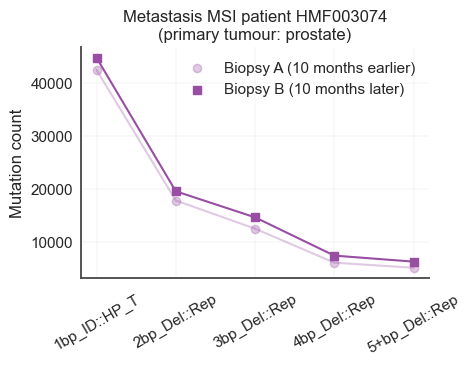

In [57]:
ax, fig = plt.subplots(figsize = (4.5,3))
items = ['1_Del_T', '2_Del_R', '3_Del_R', '4_Del_R', '5_Del_R']
items_label = ['1bp_ID::HP_T', '2bp_Del::Rep', '3bp_Del::Rep', '4bp_Del::Rep', '5+bp_Del::Rep']

p = repeat_patient_ids[0]
patient_samples = metadata.loc[[pid == p for pid in metadata['#patientId']], 'sampleId'].values
s = patient_samples[0]
values1 = []
    
for i in items:
    values1.append ((df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum()))
            
plt.plot(items_label, values1, color = sns.color_palette("Set1")[3], alpha= 0.3)
plt.scatter(items_label, values1, color = sns.color_palette("Set1")[3], alpha = 0.3,label = "Biopsy A (10 months earlier)" )
s = patient_samples[1]
values1 = []
    
for i in items:
    values1.append ((df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum()))
            
plt.plot(items_label, values1, color = sns.color_palette("Set1")[3])
plt.scatter(items_label, values1, color =  sns.color_palette("Set1")[3],  marker = ",", label = "Biopsy B (10 months later)")

plt.title("Metastasis MSI patient HMF003074\n(primary tumour: prostate)")
plt.legend(frameon= False)
plt.ylabel("Mutation count")
plt.xticks (rotation = 30)
sns.despine()
plt.savefig("./Figures/MILO_SFig9_" + p + ".pdf", bbox_inches = "tight", dpi = 300)
plt.show()

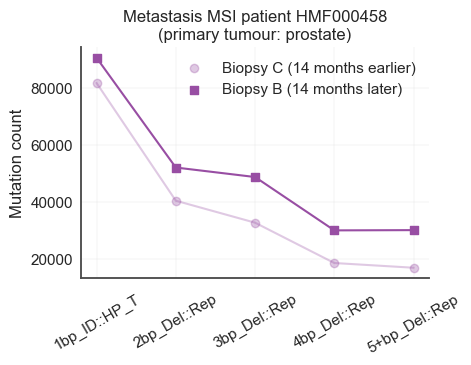

In [58]:
ax, fig = plt.subplots(figsize = (4.5,3))
items = ['1_Del_T', '2_Del_R', '3_Del_R', '4_Del_R', '5_Del_R']

p = repeat_patient_ids[1]
patient_samples = metadata.loc[[pid == p for pid in metadata['#patientId']], 'sampleId'].values
s = patient_samples[0]
values1 = []
    
for i in items:
    values1.append ((df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum()))
            
plt.plot(items_label, values1, color = sns.color_palette("Set1")[3], alpha = 0.3)
plt.scatter(items_label, values1, color = sns.color_palette("Set1")[3], alpha = 0.3,label = "Biopsy C (14 months earlier)")

s = patient_samples[1]
values1 = []
    
for i in items:
    values1.append ((df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum()))
            
plt.plot(items_label, values1, color = sns.color_palette("Set1")[3])
plt.scatter(items_label, values1, color = sns.color_palette("Set1")[3], marker = ",", label = "Biopsy B (14 months later)")
plt.title("Metastasis MSI patient HMF000458\n(primary tumour: prostate)")
plt.legend(frameon= False)
plt.xticks(rotation = 30)
plt.ylabel("Mutation count")
sns.despine()
plt.savefig("./Figures/MILO_SFig9_" + p + ".pdf", bbox_inches = "tight", dpi = 300)

plt.show()

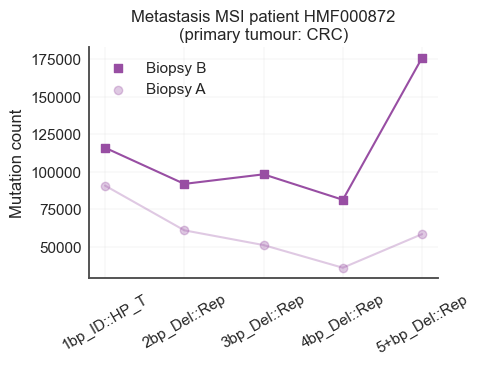

In [59]:
ax, fig = plt.subplots(figsize = (4.5,3))
items = ['1_Del_T', '2_Del_R', '3_Del_R', '4_Del_R', '5_Del_R']

p = repeat_patient_ids[2]
patient_samples = metadata.loc[[pid == p for pid in metadata['#patientId']], 'sampleId'].values
s = patient_samples[0]
values1 = []
    
for i in items:
    values1.append ((df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum()))
            
plt.plot(items_label, values1,color = sns.color_palette("Set1")[3])
plt.scatter(items_label, values1, color = sns.color_palette("Set1")[3],  marker = ",", label = "Biopsy B" )
s = patient_samples[1]
values1 = []

for i in items:
    values1.append ((df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum()))

plt.plot(items_label, values1, color = sns.color_palette("Set1")[3], alpha = 0.3)
plt.scatter(items_label, values1, color = sns.color_palette("Set1")[3], alpha = 0.3, label = "Biopsy A")
plt.title("Metastasis MSI patient HMF000872\n(primary tumour: CRC)")
plt.legend(frameon= False)
plt.ylabel("Mutation count")
plt.xticks(rotation = 30)
sns.despine()
plt.savefig("./Figures/MILO_SFig9_" + p + ".pdf", bbox_inches = "tight", dpi = 300)

plt.show()

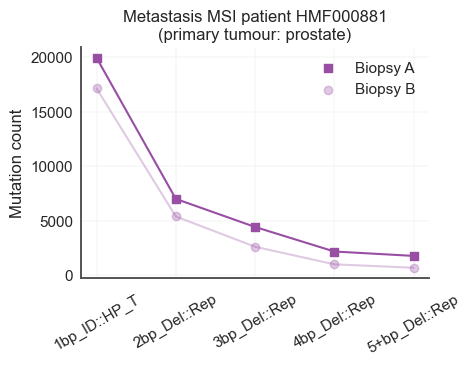

In [60]:
ax, fig = plt.subplots(figsize = (4.5,3))
items = ['1_Del_T', '2_Del_R', '3_Del_R', '4_Del_R', '5_Del_R']

p = repeat_patient_ids[3]
patient_samples = metadata.loc[[pid == p for pid in metadata['#patientId']], 'sampleId'].values
s = patient_samples[0]
values1 = []
    
for i in items:
    values1.append ((df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum()))
            
plt.plot(items_label, values1, color = sns.color_palette("Set1")[3])
plt.scatter(items_label, values1, color = sns.color_palette("Set1")[3], marker = ",", label = "Biopsy A" )
s = patient_samples[1]
values1 = []
    
for i in items:
    values1.append ((df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum()))
            
plt.plot(items_label, values1, color = sns.color_palette("Set1")[3], alpha = 0.3)
plt.scatter(items_label, values1, color = sns.color_palette("Set1")[3], alpha = 0.3, label = "Biopsy B")
plt.title("Metastasis MSI patient HMF000881\n(primary tumour: prostate)")
plt.legend(frameon= False)
plt.xticks(rotation = 30)
plt.ylabel("Mutation count")
sns.despine()
plt.savefig("./Figures/MILO_SFig9_" + p + ".pdf", bbox_inches = "tight", dpi = 300)

plt.show()

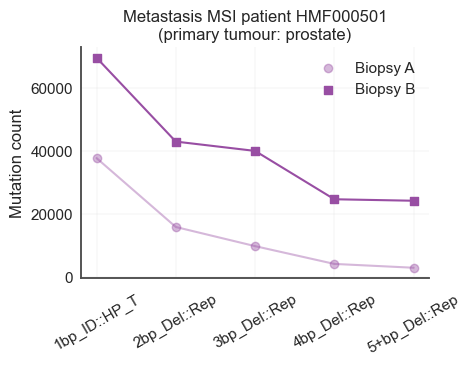

In [61]:
ax, fig = plt.subplots(figsize = (4.5,3))
items = ['1_Del_T', '2_Del_R', '3_Del_R', '4_Del_R', '5_Del_R']

p = repeat_patient_ids[4]
patient_samples = metadata.loc[[pid == p for pid in metadata['#patientId']], 'sampleId'].values
s = patient_samples[0]
values1 = []
    
for i in items:
    values1.append ((df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum()))
            
plt.plot(items_label, values1, color = sns.color_palette("Set1")[3], alpha = .4)
plt.scatter(items_label, values1, color = sns.color_palette("Set1")[3], alpha = .4 , label = "Biopsy A" )
s = patient_samples[1]
values1 = []
    
for i in items:
    values1.append ((df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum()))
            
plt.plot(items_label, values1, color = sns.color_palette("Set1")[3])
plt.scatter(items_label, values1, color = sns.color_palette("Set1")[3], marker = ",", label = "Biopsy B")
plt.title("Metastasis MSI patient HMF000501\n(primary tumour: prostate)")
plt.legend(frameon= False)
plt.xticks(rotation = 30)
plt.ylabel("Mutation count")
sns.despine()
plt.savefig("./Figures/MILO_SFig9_" + p + ".pdf", bbox_inches = "tight", dpi = 300)
plt.show()

### Accumulation pattern in longitudinal samples with annotated biopsy time

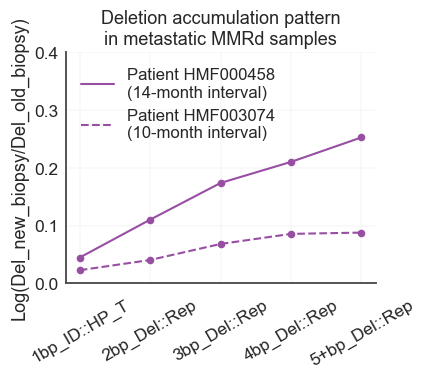

In [62]:
ax, fig = plt.subplots(figsize = (4,3))

p = repeat_patient_ids[1]
patient_samples = metadata.loc[[pid == p for pid in metadata['#patientId']], 'sampleId'].values
s = patient_samples[0]
values1 = []
    
for i in items:
    values1.append (df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum())

s = patient_samples[1]
values2 = []
    
for i in items:
    values2.append (df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum())
            
plt.plot(items_label, np.log10(np.array(values2)/(np.array(values1) + 0.000001)), color = sns.color_palette("Set1")[3], 
         label = "Patient HMF000458\n(14-month interval)")
plt.scatter(items_label, np.log10(np.array(values2)/(np.array(values1) + 0.000001)), s = 20, 
            color = sns.color_palette("Set1")[3])

p = repeat_patient_ids[0]
patient_samples = metadata.loc[[pid == p for pid in metadata['#patientId']], 'sampleId'].values
s = patient_samples[0]
values1 = []
    
for i in items:
    values1.append (df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum())

s = patient_samples[1]
values2 = []
    
for i in items:
    values2.append (df_HW_MSI_ID.loc[s, [i in c for c in df_HW_MSI_ID.columns]].sum())
            
plt.plot(items_label, np.log10(np.array(values2)/(np.array(values1) + 0.000001)), linestyle= '--', 
         color = sns.color_palette("Set1")[3], label = "Patient HMF003074\n(10-month interval)")
plt.scatter(items_label, np.log10(np.array(values2)/(np.array(values1) + 0.000001)) , s = 20, 
            color = sns.color_palette("Set1")[3])

plt.legend(frameon = False, loc = "upper left")
sns.despine()


plt.xticks (rotation = 30, fontsize = 12.5)
plt.yticks (fontsize = 12.5)
plt.xlabel("")
sns.despine()
plt.ylabel ("Log(Del_new_biopsy/Del_old_biopsy)", fontsize =13)
plt.title('Deletion accumulation pattern\nin metastatic MMRd samples', size = 13)

plt.ylim (0,0.28)

plt.legend (loc = 'upper left', frameon = False, fontsize = 12)
plt.ylim(0,0.4)

plt.savefig("./Figures/MILO_Fig2j.pdf", bbox_inches = "tight", dpi = 300)

plt.show()

# Weak but distinguishable long deletion signals in primary MMRd tumours

## Selected feature count comparison of three datasets

In [63]:
peaks_MSI_ID_sig3 = list(df_GEL_MSI_ID.columns[:83][inferred_id_sigs_nsig5['MSI_ID_sig3'] > 0.05].values)

In [64]:
df_PCAWG_peaks = df_PCAWG.loc[:, peaks_MSI_ID_sig3 + ['MSI_status']]
df_PCAWG_peaks['data_source'] = 'PCAWG'

In [65]:
df_GEL_peaks = df_GEL.loc[:, peaks_MSI_ID_sig3 + ['MSI_status']]
df_GEL_peaks['data_source'] = 'GEL'

In [66]:
df_EPICC_peaks = df_EPICC.loc[:, peaks_MSI_ID_sig3 + ['MSI_status']]
df_EPICC_peaks['data_source'] = 'EPICC'

In [67]:
df_combined_primary_samples_peaks = pd.concat((df_GEL_peaks,  df_EPICC_peaks, df_PCAWG_peaks))
df_combined_primary_samples_peaks.head(2)

,2_Del_R_4,2_Del_R_5,3_Del_R_3,3_Del_R_4,4_Del_R_2,4_Del_R_3,5_Del_R_1,5_Del_R_2,MSI_status,data_source
sample1,0,28,0,0,3,1,16,7,0,GEL
sample2,10,40,0,0,2,1,15,5,0,GEL


In [68]:
df_combined_primary_samples_peaks_melted = df_combined_primary_samples_peaks.melt(id_vars = ['MSI_status','data_source'])

df_combined_primary_samples_peaks_melted = df_combined_primary_samples_peaks_melted.rename({'variable': 'Peak'}, axis = 1) 
df_combined_primary_samples_peaks_melted['value'] = np.log(df_combined_primary_samples_peaks_melted['value'] + 1)

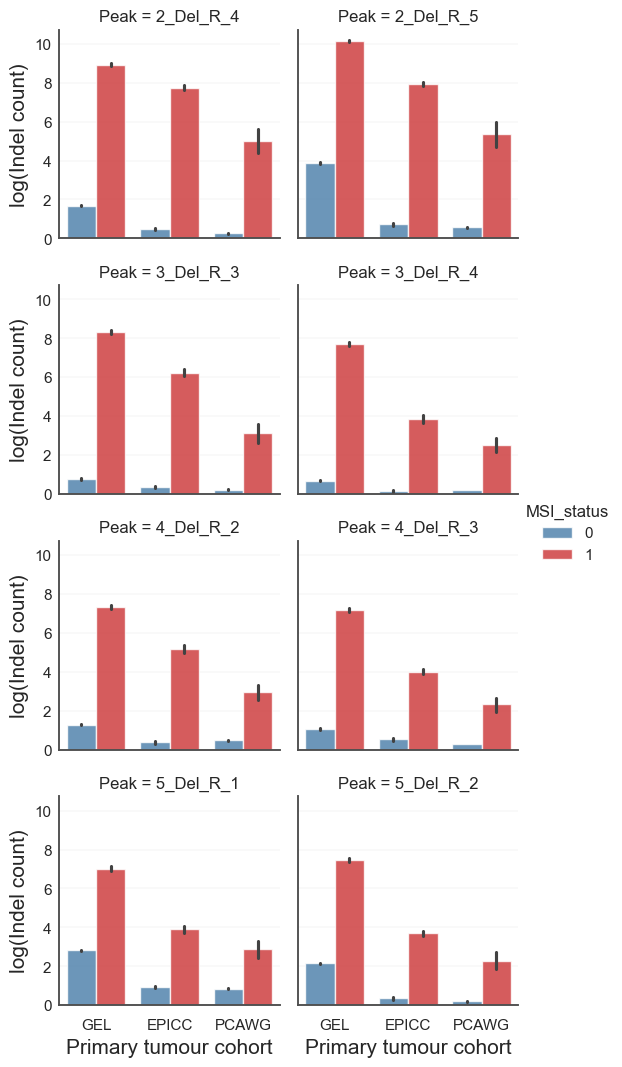

In [69]:
f = sns.catplot(data = df_combined_primary_samples_peaks_melted, x = "data_source", y = "value", 
            palette= {0:sns.color_palette("Set1")[1], 1:sns.color_palette("Set1")[0]},
            hue =  'MSI_status', col = 'Peak', kind='bar', col_wrap = 2,
                alpha = .8, height = 2.7, aspect=1, sharey = True)
f.set_xlabels('Primary tumour cohort', fontsize=15) # not set_label
f.set_ylabels('log(Indel count)', fontsize=15)
plt.savefig("./Figures/MILO_SFig11.pdf", bbox_inches = "tight", dpi = 300)

plt.show()

# Relationship between long deletions and patient outcomes

In [70]:
import time
import datetime

from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import pairwise_logrank_test

## Overall survival(OS) analysis

### Time intervals and events

In [71]:
msi_metadata = metadata.loc[metadata['msStatus'] == 'MSI',:]
msi_mini_metadata = msi_metadata.loc[:, ["sampleId", "birthYear", 'biopsyDate',"deathDate",
                                         'primaryTumorLocation','hasSystemicPreTreatment', 
                                         'hasRadiotherapyPreTreatment', 'treatmentGiven', 
                                         'treatmentStartDate', 'treatmentEndDate', 'treatment',
                                         'treatmentType', 'responseDate', 'responseMeasured', 'firstResponse']]

In [72]:
msi_mini_metadata['Death'] = [i == True for i in msi_mini_metadata['deathDate'].notna()]
index = msi_mini_metadata ['biopsyDate'].notna()
msi_mini_metadata_biospsydate = msi_mini_metadata.loc[index,:].copy()

In [73]:
durations2 = []

for i in range(sum(index)):
    t1 = datetime.datetime.strptime(msi_mini_metadata_biospsydate.loc[:,'biopsyDate'].values[i],"%Y-%m-%d")
    
    if msi_mini_metadata_biospsydate.loc[:,'Death'].values[i] == True:
        t2 = datetime.datetime.strptime(msi_mini_metadata_biospsydate.loc[:,'deathDate'].values[i],"%Y-%m-%d")
        
    elif msi_mini_metadata_biospsydate.loc[:,'treatmentEndDate'].notna().values[i]:
            t2 = datetime.datetime.strptime(msi_mini_metadata_biospsydate.loc[:,'treatmentEndDate'].values[i],"%Y-%m-%d")
    else: 
            t2 = datetime.datetime.strptime('2019-07-15',"%Y-%m-%d")
    
    d1 = (t2-t1).days
    
    durations2.append(d1)

msi_mini_metadata_biospsydate.loc[:, 'duration'] = durations2

## Summarising metrics

In [74]:
items = ['1_Del_T', '2_Del_R', '3_Del_R', '4_Del_R', '5_Del_R']
hw_msi_patients = df_HW_MSI.index.values

df_tmp = pd.DataFrame({'sample' : hw_msi_patients,
                       '1_Del_T' : [0] * len(hw_msi_patients), 
                       '2_Del_R' : [0] * len(hw_msi_patients),
                       '3_Del_R' : [0] * len(hw_msi_patients), 
                       '4_Del_R' : [0] * len(hw_msi_patients),
                       '5_Del_R' : [0] * len(hw_msi_patients)})

## Long deletion intensity
for p in hw_msi_patients:
    for i in items:
        value = df_HW_MSI_ID_norm.loc[p, [i in c for c in df_HW_MSI_ID_norm.columns]].sum()
        df_tmp.loc[df_tmp['sample']== p, i] = value
        
df_tmp['long_del_intensity'] = (df_tmp.iloc[:, 2:6] * np.array([2,3,4,5])).sum(axis = 1)

## TMB
total_tmb = df_HW_MSI.iloc[:,:].sum(axis=1).values
df_tmp['TMB'] = total_tmb #df_tmp.iloc[:, 1:6].sum(axis = 1)

### Merge and group data

In [75]:
msi_mini_metadata_biospsydate_merge = msi_mini_metadata_biospsydate.merge(df_tmp, left_on= "sampleId", right_on = "sample")

In [76]:
cutoff_TMB = np.percentile(msi_mini_metadata_biospsydate_merge['TMB'], [50])[-1]
cutoff_Ldel_intensity = np.percentile(msi_mini_metadata_biospsydate_merge['long_del_intensity'], [50])[-1]
cutoff_1Del_prop = np.percentile(msi_mini_metadata_biospsydate_merge['1_Del_T'], [50])[-1]

In [77]:
## TMB
msi_mini_metadata_biospsydate_merge['TMB_quantile'] = 0
msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge['TMB'] > cutoff_TMB, 'TMB_quantile'] = 1

## long deletion intensity
msi_mini_metadata_biospsydate_merge['LDel_quantile'] = 0
msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge['long_del_intensity'] > cutoff_Ldel_intensity, 'LDel_quantile'] = 1

## 1bp
msi_mini_metadata_biospsydate_merge['1Del_quantile'] = 0

msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge['1_Del_T'] > cutoff_1Del_prop, '1Del_quantile'] = 1


### Long deletion intensity vs OS

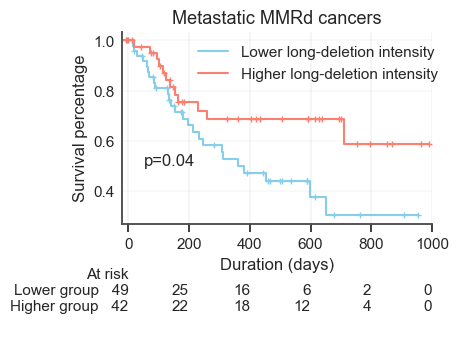

In [78]:
## fit the model for 1st cohort
fig, ax = plt.subplots(figsize = (4,2.5))
sns.set(style="whitegrid", color_codes=True, rc={"grid.linewidth": 0.02, 'grid.color': '.02', 
                                                     'ytick.major.size': 1,'axes.edgecolor': '.02',
                                                     'axes.linewidth': 1,"figure.figsize":(5,3)})
f1 = KaplanMeierFitter()
f1.fit(msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge['LDel_quantile'] == 0,'duration'], 
         msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge['LDel_quantile'] == 0, 'Death'],
        label = "Lower group")
f1.plot(ci_show = False,show_censors=True, censor_styles={'ms': 5}, color = 'skyblue')

## fit the model for 2nd cohort
f2 = KaplanMeierFitter()

f2.fit(msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge['LDel_quantile'] == 1,'duration'], 
         msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge['LDel_quantile'] == 1,'Death'], 
         label='Higher group')

f2.plot(ci_show = False, show_censors=True, censor_styles={'ms': 5}, color = "salmon")

plt.ylabel("Survival percentage")
plt.xlabel("Duration (days)")

a = pairwise_logrank_test(event_durations= msi_mini_metadata_biospsydate_merge['duration'][msi_mini_metadata_biospsydate_merge['duration']>0],
                      groups = msi_mini_metadata_biospsydate_merge["LDel_quantile"][msi_mini_metadata_biospsydate_merge['duration']>0], 
                      event_observed=msi_mini_metadata_biospsydate_merge["Death"][msi_mini_metadata_biospsydate_merge['duration']>0])
p = a.summary.iloc[0,1]

plt.text (50, 0.5, 'p={0:.1}'.format(p))
plt.xlim(-20,1000)
plt.title('Metastatic MMRd cancers', fontsize = 13)

handles, previous_labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Lower long-deletion intensity' , 'Higher long-deletion intensity'], frameon = False, bbox_to_anchor = (0.2, 1))
sns.despine()
add_at_risk_counts(f1, f2, ax=ax, fig = fig,rows_to_show=['At risk'], ypos=-0.3)

plt.savefig("./Figures//MILO_Fig3a.pdf",dpi = 300, bbox_inches = "tight")
plt.show()

### TMB vs OS

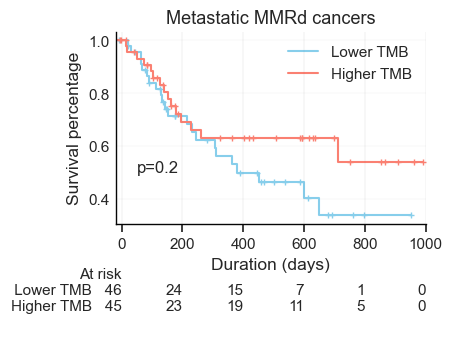

In [79]:
## fit the model for 1st cohort
fig, ax = plt.subplots(figsize = (4,2.5))
sns.set(style="whitegrid", color_codes=True, rc={"grid.linewidth": 0.02, 'grid.color': '.02', 
                                                     'ytick.major.size': 1,'axes.edgecolor': '.02',
                                                     'axes.linewidth': 1,"figure.figsize":(5,3)})

f1 = KaplanMeierFitter()
f1.fit(msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge['TMB_quantile'] == 0,'duration'], 
         msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge['TMB_quantile'] == 0, 'Death'], 
         label = 'Lower TMB')

f1.plot(ci_show = False,show_censors=True, censor_styles={'ms': 5}, color = 'skyblue')

## fit the model for 2nd cohort
f2 = KaplanMeierFitter()

f2.fit(msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge['TMB_quantile'] == 1,'duration'], 
         msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge['TMB_quantile'] == 1,'Death'], 
         label='Higher TMB')

f2.plot(ci_show = False, show_censors = True, censor_styles = {'ms': 5}, color = "salmon")

plt.ylabel("Survival percentage", fontsize = 12.5)
plt.xlabel("Duration (days)", fontsize = 12.5)

a = pairwise_logrank_test(event_durations = msi_mini_metadata_biospsydate_merge['duration'][msi_mini_metadata_biospsydate_merge['duration']>0],
                      groups = msi_mini_metadata_biospsydate_merge["TMB_quantile"][msi_mini_metadata_biospsydate_merge['duration']>0], 
                      event_observed = msi_mini_metadata_biospsydate_merge["Death"][msi_mini_metadata_biospsydate_merge['duration']>0])

p = a.summary.iloc[0,1]

plt.text (50, 0.5, 'p={0:.1}'.format(p))
plt.xlim(-20,1000)
plt.title('Metastatic MMRd cancers', fontsize = 13)
sns.despine()
plt.legend(frameon = False)
add_at_risk_counts(f1, f2, ax=ax, fig = fig, rows_to_show=['At risk'], ypos=-0.3)

plt.savefig("./Figures/MILO_Fig3b.pdf",dpi = 300, bbox_inches = "tight")
plt.show()

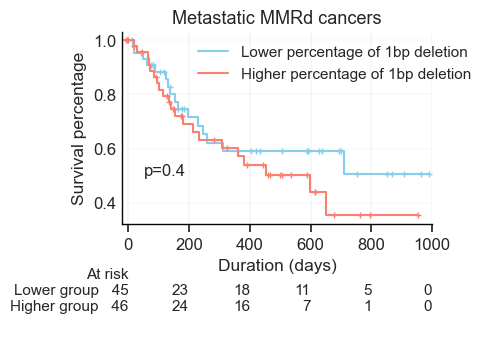

In [80]:
## fit the model for 1st cohort
var = '1Del_quantile'

fig, ax = plt.subplots(figsize = (4,2.5))
sns.set(style="whitegrid", color_codes=True, rc={"grid.linewidth": 0.02, 'grid.color': '.02', 
                                                     'ytick.major.size': 1,'axes.edgecolor': '.02',
                                                     'axes.linewidth': 1,"figure.figsize":(5,3)}) 
f1 = KaplanMeierFitter()
f1.fit(msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge[var] == 0,'duration'], 
         msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge[var] == 0, 'Death'],
        label = "Lower group")
f1.plot(ci_show = False,show_censors=True, censor_styles={'ms': 5}, color = 'skyblue')


## fit the model for 2nd cohort
f2 = KaplanMeierFitter()

f2.fit(msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge[var] == 1,'duration'], 
         msi_mini_metadata_biospsydate_merge.loc[msi_mini_metadata_biospsydate_merge[var] == 1,'Death'], 
         label = 'Higher group')
f2.plot(ci_show = False, show_censors=True, censor_styles={'ms': 5}, color = "salmon")

plt.ylabel("Survival percentage", fontsize = 12.5)
plt.xlabel("Duration (days)", fontsize = 12.5)

handles, previous_labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Lower percentage of 1bp deletion' , 'Higher percentage of 1bp deletion'], frameon = False, bbox_to_anchor = (0.2, 1))

a = pairwise_logrank_test(event_durations= msi_mini_metadata_biospsydate_merge['duration'][msi_mini_metadata_biospsydate_merge['duration']>0],
                      groups = msi_mini_metadata_biospsydate_merge[var][msi_mini_metadata_biospsydate_merge['duration']>0], 
                      event_observed=msi_mini_metadata_biospsydate_merge["Death"][msi_mini_metadata_biospsydate_merge['duration']>0])
p = a.summary.iloc[0,1]

plt.text (50, 0.5, 'p={0:.1}'.format(p))
plt.xlim(-20,1000)
plt.title('Metastatic MMRd cancers', fontsize = 13)
plt.yticks(fontsize = 12)
plt.xticks(fontsize = 12)

sns.despine()

add_at_risk_counts(f1, f2, ax=ax, fig = fig,rows_to_show=['At risk'],ypos=-0.3)

plt.savefig("./Figures/MILO_Fig3c.pdf",dpi = 300, bbox_inches = "tight")
plt.show()

## Long-deletion intensity vs OS

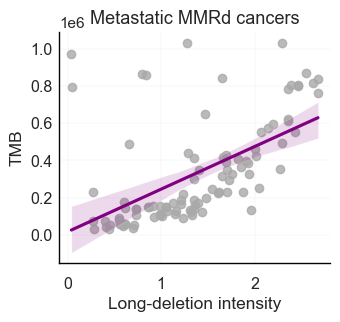

SignificanceResult(statistic=0.6849444944494448, pvalue=3.876498029533997e-15)


In [81]:
f, ax = plt.subplots(figsize = (3.5,3))

sns.regplot(x = 'long_del_intensity', y = 'TMB',
           data = msi_mini_metadata_biospsydate_merge, 
            scatter_kws = {"color": "darkgrey", "alpha": 0.8},
            line_kws = {"color": "purple"})


plt.xlabel("Long-deletion intensity", fontsize = 12.5)
plt.ylabel(f"TMB", fontsize = 12.5)
plt.xticks (fontsize = 11.5)
plt.yticks (fontsize = 11.5)

plt.title("Metastatic MMRd cancers", fontsize = 13)
sns.despine()
plt.savefig("./Figures//MILO_Fig3d.pdf",dpi = 300, bbox_inches = "tight")
plt.show()

x = msi_mini_metadata_biospsydate_merge['long_del_intensity']
y = msi_mini_metadata_biospsydate_merge['TMB']
stat = stats.spearmanr(x, y)
print (stat)

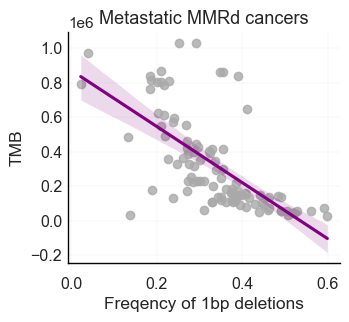

SignificanceResult(statistic=-0.7321812181218121, pvalue=4.92268562786573e-18)


In [82]:
f, ax = plt.subplots(figsize = (3.5,3))

sns.regplot(x = '1_Del_T', y = 'TMB', ci=95,
           data = msi_mini_metadata_biospsydate_merge,scatter_kws = {"color": "darkgrey", "alpha": 0.8},
            line_kws = {"color": "purple"})


plt.xlabel("Freqency of 1bp deletions", fontsize = 12.5)
plt.ylabel(f"TMB", fontsize = 12.5)
plt.xticks (fontsize = 11.5)
plt.yticks (fontsize = 11.5)

plt.title("Metastatic MMRd cancers", fontsize = 13)

sns.despine()
plt.savefig("./Figures//MILO_Fig3e.pdf",dpi = 300, bbox_inches = "tight")

plt.show()

x = msi_mini_metadata_biospsydate_merge['1_Del_T']
y = msi_mini_metadata_biospsydate_merge['TMB']

stat = stats.spearmanr(x, y)

print (stat)

## Progression free survival (PFS) analysis

In [83]:
durations = []
di_pos_index = np.logical_and (msi_mini_metadata['biopsyDate'].notna(),msi_mini_metadata['responseDate'].notna())

for i in range(sum(di_pos_index)):
    t1 = datetime.datetime.strptime(msi_mini_metadata.loc[di_pos_index, 'biopsyDate'].values[i],"%Y-%m-%d")
    t2 = datetime.datetime.strptime(msi_mini_metadata.loc[di_pos_index, 'responseDate'].values[i],"%Y-%m-%d")
    d1 = (t2-t1).days
    durations.append(d1)
    
msi_mini_metadata_response = msi_mini_metadata.loc[di_pos_index, :].copy()
msi_mini_metadata_response['duration'] = durations
msi_mini_metadata_response['Response'] = [i == 'PD' for i in msi_mini_metadata_response['firstResponse']]

In [84]:
msi_mini_metadata_response_merged = msi_mini_metadata_response.merge(df_tmp, left_on = "sampleId", right_on = "sample")

cutoff_Ldel_intensity2 = np.percentile(msi_mini_metadata_response_merged['long_del_intensity'], [50])[-1]

In [85]:
msi_mini_metadata_response_merged['LDel_quantile'] = 0
msi_mini_metadata_response_merged.loc[msi_mini_metadata_response_merged['long_del_intensity'] > 
                                              cutoff_Ldel_intensity2, 'LDel_quantile'] = 1

In [86]:
msi_mini_metadata_response_merged.shape

(36, 27)

### Other treatment

In [87]:
msi_mini_metadata_response_merged_nochemo = msi_mini_metadata_response_merged.loc[msi_mini_metadata_response_merged['treatmentType'] != 'Chemotherapy',:].copy()

In [88]:
msi_mini_metadata_response_merged_nochemo.shape

(19, 27)

In [89]:
msi_mini_metadata_response_merged_nochemo.groupby("treatmentType").count()['sampleId']

treatmentType
Hormonal therapy     3
Immunotherapy        5
Multiple therapy    10
Targeted therapy     1
Name: sampleId, dtype: int64

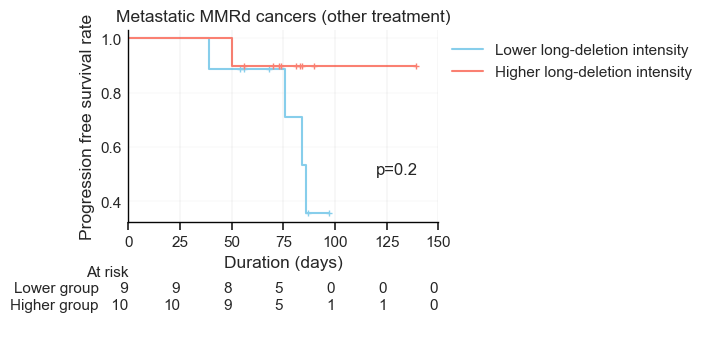

In [90]:
## fit the model for 1st cohort
fig, ax = plt.subplots(figsize = (4,2.5))
sns.set(style="whitegrid", color_codes=True, rc={"grid.linewidth": 0.02, 'grid.color': '.02', 
                                                     'ytick.major.size': 1,'axes.edgecolor': '.02',
                                                     'axes.linewidth': 1,"figure.figsize":(5,3)}) 
f1 = KaplanMeierFitter()
f1.fit(msi_mini_metadata_response_merged_nochemo.loc[msi_mini_metadata_response_merged_nochemo['LDel_quantile'] == 0,'duration'], 
         msi_mini_metadata_response_merged_nochemo.loc[msi_mini_metadata_response_merged_nochemo['LDel_quantile'] == 0, 'Response'],
        label = "Lower group")
f1.plot(ci_show = False,show_censors=True, censor_styles={'ms': 5}, color = 'skyblue')

## fit the model for 2nd cohort
f2 = KaplanMeierFitter()

f2.fit(msi_mini_metadata_response_merged_nochemo.loc[msi_mini_metadata_response_merged_nochemo['LDel_quantile'] == 1,'duration'], 
         msi_mini_metadata_response_merged_nochemo.loc[msi_mini_metadata_response_merged_nochemo['LDel_quantile'] == 1,'Response'], 
         label='Higher group')
f2.plot(ci_show = False, show_censors=True, censor_styles={'ms': 5}, color = "salmon")

plt.ylabel("Progression free survival rate", fontsize = 12.5)
plt.xlabel("Duration (days)", fontsize = 12.5)

a = pairwise_logrank_test(event_durations = msi_mini_metadata_response_merged_nochemo['duration'][msi_mini_metadata_response_merged_nochemo['duration']>0],
                      groups = msi_mini_metadata_response_merged_nochemo["LDel_quantile"][msi_mini_metadata_response_merged_nochemo['duration']>0], 
                      event_observed = msi_mini_metadata_response_merged_nochemo["Response"][msi_mini_metadata_response_merged_nochemo['duration']>0])
p = a.summary.iloc[0,1]

plt.text (120, 0.5, 'p={0:.1}'.format(p))
plt.xlim(0,150)
plt.title('Metastatic MMRd cancers (other treatment)', fontsize = 12.5)
sns.despine()
handles, previous_labels = ax.get_legend_handles_labels()
ax.legend(handles = handles, labels = ['Lower long-deletion intensity', 'Higher long-deletion intensity'], frameon = False, bbox_to_anchor = (1, 1))
add_at_risk_counts(f1, f2, ax = ax, fig = fig,rows_to_show = ['At risk'], ypos = -0.3)

plt.savefig("./Figures//MILO_SFig10.pdf",dpi = 300, bbox_inches = "tight")
plt.show()

### Chemotherapy

In [91]:
msi_mini_metadata_response_merged_onlychemo = msi_mini_metadata_response_merged.loc[msi_mini_metadata_response_merged['treatmentType']=='Chemotherapy',:]

In [92]:
msi_mini_metadata_response_merged_onlychemo.groupby (['firstResponse']).count()

,sampleId,birthYear,biopsyDate,deathDate,primaryTumorLocation,hasSystemicPreTreatment,hasRadiotherapyPreTreatment,treatmentGiven,treatmentStartDate,treatmentEndDate,...,Response,sample,1_Del_T,2_Del_R,3_Del_R,4_Del_R,5_Del_R,long_del_intensity,TMB,LDel_quantile
firstResponse,,,,,,,,,,,,,,,,,,,,,
PD,11,11,11,9,11,11,11,11,11,11,...,11,11,11,11,11,11,11,11,11,11
PR,3,3,3,0,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
SD,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3


# Overfiltering of long deletion mutations by popular mutation caller

We investigated why we did not observe long-deletion signals in Supplementary Fig. 1a-c but did see them in the low-pass data in Fig. 4e using n=214 EPICC samples. Specifically, we studied those indel mutations that were not given a 'PASS' tag by Mutect2. We classified these non-passed indels into loci with a single allele and those labeled as 'multiallelic.' The final matrix data are from the passed indels reported in the original EPICC paper.

In [93]:
## reading data:
df_notpassed_t = pd.read_csv ("./Data/EPICC_mutect2_notpassed_single_allele_indels.csv", index_col = 0)
df_allele1_t = pd.read_csv ("./Data/EPICC_mutect2_notpassed_multiallelic_indels.csv", index_col = 0)
df_final = pd.read_csv ("./Data/EPICC_final_passed_indels.csv", index_col = 0)
df_notpassed_t.shape, df_allele1_t.shape, df_final.shape

((214, 181), (214, 181), (214, 180))

## Compare filtered mutations between MSI and MSS

In [94]:
df_filtered = df_notpassed_t.copy()
df_filtered = df_filtered.set_index ('sample').copy()

df_filtered.iloc[:,:179] = df_notpassed_t.iloc [:, :179].values + df_allele1_t.iloc [:, :179].values

In [95]:
filtered_df_count_df = pd.DataFrame({'Count' : list(df_filtered.iloc[:,:96].sum(axis = 1).values) + list(df_filtered.iloc[:,96:179].sum(axis = 1).values),
                                 'Mutations': ['SNVs'] * df_filtered.shape[0] + ['Indels'] * df_filtered.shape[0],
                                 'MSI status' : list(df_filtered['MSI_status'].values) * 2})
filtered_df_count_df.head()

,Count,Mutations,MSI status
0,121191,SNVs,1
1,252323,SNVs,1
2,190206,SNVs,1
3,141560,SNVs,1
4,180711,SNVs,1


In [96]:
sum(df_filtered['MSI_status'].values == 0)

182

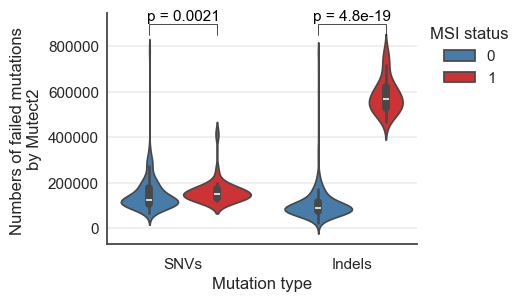

In [97]:
sns.set(style="whitegrid", color_codes=True, rc={"grid.linewidth": 0.3, 'grid.color': '.7', 'ytick.major.size': 2,
                                                'axes.edgecolor': '.3', 'axes.linewidth': 1.35,})

f, ax = plt.subplots(figsize = (4,3))
sns.violinplot (x = 'Mutations', y = 'Count', hue = 'MSI status', data = filtered_df_count_df,
               palette= {0:sns.color_palette("Set1")[1], 1:sns.color_palette("Set1")[0]})

MMRp_SNV = filtered_df_count_df.loc [ np.logical_and(filtered_df_count_df['MSI status'] == 0, 
                                                     filtered_df_count_df['Mutations'] == 'SNVs'), 'Count'].values
MMRd_SNV = filtered_df_count_df.loc [ np.logical_and(filtered_df_count_df['MSI status'] == 1, 
                                                     filtered_df_count_df['Mutations'] == 'SNVs'), 'Count'].values

t_snv, p_snv = mannwhitneyu(MMRp_SNV, MMRd_SNV,  alternative = 'two-sided')

x1, x2 = -0.20, 0.20
y, h, col = 850000, 50000, 'black'
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.5, c = col)

ax.text((x1+x2)*.5, y + h + 0.02, 'p = {:.4f}'.format(p_snv), ha='center', 
                        va='bottom', color=col, size = 11)

MMRp_indels = filtered_df_count_df.loc [ np.logical_and(filtered_df_count_df['MSI status'] == 0, 
                                                        filtered_df_count_df['Mutations'] == 'Indels'), 'Count'].values
MMRd_indels = filtered_df_count_df.loc [ np.logical_and(filtered_df_count_df['MSI status'] == 1, 
                                                        filtered_df_count_df['Mutations'] == 'Indels'), 'Count'].values

t_indel, p_indel = mannwhitneyu(MMRp_indels, MMRd_indels, alternative='two-sided')

x1, x2 = 0.8, 1.2
y, h, col =  850000, 50000, 'black'
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.5, c = col)
    
ax.text((x1+x2)*.5, y + h + 0.02, 'p = {0:1.1e}'.format(p_indel), ha='center', va='bottom', color=col, size = 11)

plt.ylabel ('Numbers of failed mutations \nby Mutect2')
plt.legend(title='MSI status', bbox_to_anchor = (1,1), frameon = False)
plt.xlabel("Mutation type")
sns.despine()
plt.savefig("./Figures/MILO_SFig21a.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

In [98]:
filtered_df_count_df.groupby(['MSI status', 'Mutations']).mean()

Count
MSI status Mutations               
0          Indels     104163.395604
           SNVs       149347.219780
1          Indels     583577.812500
           SNVs       161886.250000

## Comparing filtered and passed indel mutation count in MSI samples

In [99]:
df_final_MSI = df_final.loc [df_final['MSI_status'] == 1, :].copy()
df_final_MSI ['Final_filtered_Indels'] = df_final_MSI.iloc[:,96:179].sum(axis = 1)

In [100]:
df_notpassed_MSI = df_notpassed_t.loc [df_notpassed_t['MSI_status'] == 1, :].copy()
df_notpassed_MSI ['Failed_indels(single_allele)'] = df_notpassed_MSI.iloc[:,96:179].sum(axis = 1)

In [101]:
df_allele1_MSI = df_allele1_t.loc [df_allele1_t['MSI_status'] == 1, :].copy()
df_allele1_MSI ['Failed_indels(multiallelic_first_allele)'] = df_allele1_MSI.iloc[:,96:179].sum(axis = 1)

In [102]:
df_final_MSI ['sample'] = df_final_MSI.index.values

In [103]:
df_MSI_indel_count1 = df_final_MSI.iloc[:,180:].merge (df_allele1_MSI .iloc[:,179:], 
                                                      left_on = 'sample', 
                                                      right_on = 'sample').merge(df_notpassed_MSI .iloc[:,179:], 
                                                                                 left_on = 'sample', 
                                                                                 right_on = 'sample')

In [104]:
df_MSI_indel_count2 = df_MSI_indel_count1.drop (columns=['MSI_status_x','MSI_status_y']).copy()
df_MSI_indel_count3 = df_MSI_indel_count2.set_index('sample')

In [105]:
df_MSI_indel_count3['Total'] = df_MSI_indel_count3.loc[:,['Final_filtered_Indels', 'Failed_indels(single_allele)',
                           'Failed_indels(multiallelic_first_allele)']].sum(axis = 1)

df_MSI_indel_count4 = df_MSI_indel_count3.sort_values('Total', ascending  = False)

In [106]:
df_MSI_indel_count4.shape
(df_MSI_indel_count4['Final_filtered_Indels']/df_MSI_indel_count4['Total']).mean()

0.15261313502182489

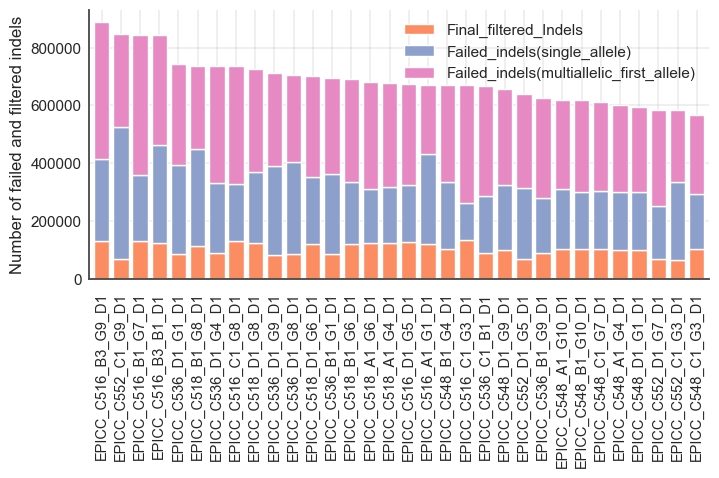

In [107]:
df_MSI_indel_count4.loc[:,['Final_filtered_Indels', 'Failed_indels(single_allele)',
                           'Failed_indels(multiallelic_first_allele)']].plot(kind='bar',width = 0.8, stacked=True, 
                                                                             color = sns.color_palette('Set2')[1:4],
                                                                            figsize=(8, 3.5))
sns.despine()
plt.legend(frameon = False, loc = 'upper right')
plt.xlabel("")
plt.xticks(fontsize = 10.5)
plt.ylabel('Number of failed and filtered indels')
plt.savefig("./Figures/MILO_SFig21b.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

## Mutation profiles of passed and filtered indels

In [108]:
df_final_MSI_norm = df_final_MSI.copy()
df_final_MSI_norm.iloc[:,:96] = df_final_MSI.iloc[:,:96].div(df_final_MSI.iloc[:,:96].sum(axis=1), axis=0).copy()
df_final_MSI_norm.iloc[:,96:179] = df_final_MSI.iloc[:,96:179].div(df_final_MSI.iloc[:,96:179].sum(axis=1), axis=0).copy()

In [109]:
df_notpassed_MSI_norm = df_notpassed_MSI.copy()
df_notpassed_MSI_norm.iloc[:,:96] = df_notpassed_MSI.iloc[:,:96].div(df_notpassed_MSI.iloc[:,:96].sum(axis=1), axis=0).copy()
df_notpassed_MSI_norm.iloc[:,96:179] = df_notpassed_MSI.iloc[:,96:179].div(df_notpassed_MSI.iloc[:,96:179].sum(axis=1), axis=0).copy()

In [110]:
df_allele1_MSI_norm = df_allele1_MSI.copy()
df_allele1_MSI_norm.iloc[:,:96] = df_allele1_MSI.iloc[:,:96].div(df_allele1_MSI.iloc[:,:96].sum(axis=1), axis=0).copy()
df_allele1_MSI_norm.iloc[:,96:179] = df_allele1_MSI.iloc[:,96:179].div(df_allele1_MSI.iloc[:,96:179].sum(axis=1), axis=0).copy()

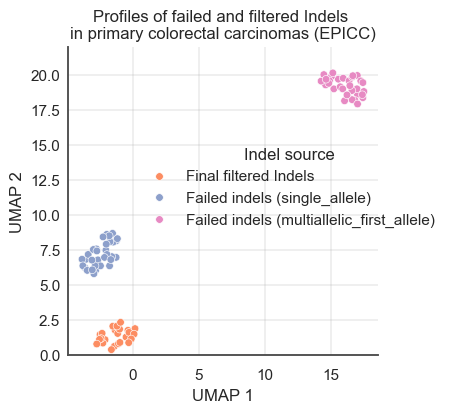

In [111]:
x = pd.concat((df_final_MSI_norm.iloc[:,96:179],df_notpassed_MSI_norm.iloc[:,96:179], df_allele1_MSI_norm.iloc[:,96:179]))
X = x.copy()
pipe = make_pipeline(SimpleImputer(strategy="mean"), QuantileTransformer())
X = pipe.fit_transform(X.copy())

# Fit UMAP to processed data
manifold = umap.UMAP(random_state=123, n_neighbors = 40, min_dist= 0.4).fit(X)

X_reduced_4 = manifold.transform(X)

df_umap = pd.DataFrame (X_reduced_4, columns= ["UMAP 1", "UMAP 2"])
df_umap['data source'] = ['Final filtered Indels'] * df_final_MSI.shape[0] + ['Failed indels (single_allele)'] * df_notpassed_MSI.shape[0] + ['Failed indels (multiallelic_first_allele)'] * df_allele1_MSI.shape[0]

f, ax = plt.subplots(figsize = (4,4))

sns.scatterplot(x = "UMAP 1", y = "UMAP 2", hue = 'data source', data = df_umap, 
                palette= sns.color_palette("Set2")[1:4], s= 30)
plt.ylim(0,22)
plt.title (f"Profiles of failed and filtered Indels \nin primary colorectal carcinomas (EPICC)")

plt.legend(bbox_to_anchor = (0.2,0.72), title = "Indel source", frameon = False)
sns.despine()
plt.savefig("./Figures/MILO_SFig21c.pdf", bbox_inches = "tight", dpi = 300)

plt.show()

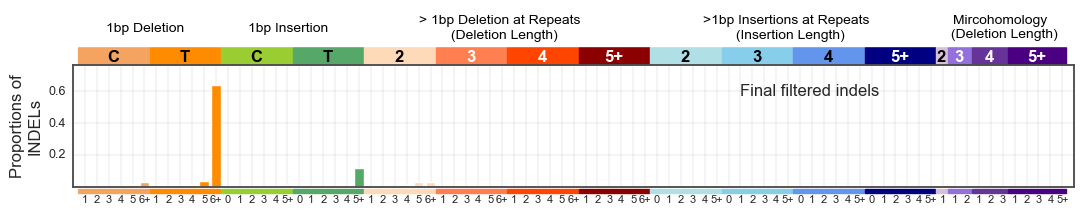

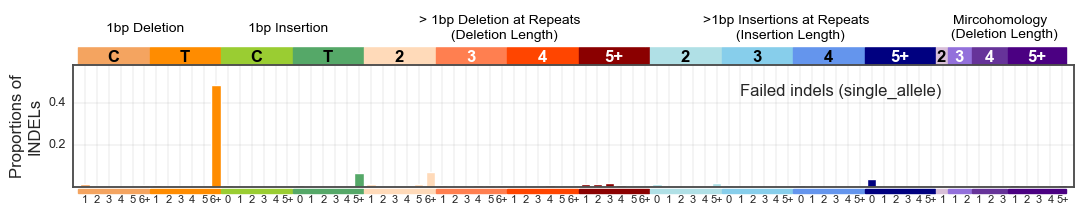

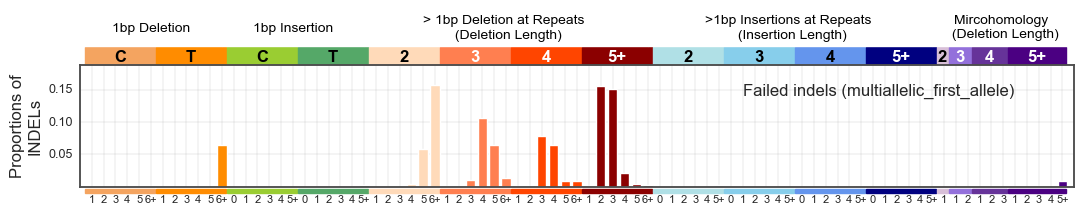

In [112]:
ID83_plot(df_final_MSI_norm.iloc[:,96:179].mean(), norm = True, name = 'Final filtered indels', file = './Figures/MILO_SFig19d1.pdf')
ID83_plot(df_notpassed_MSI_norm.iloc[:,96:179].mean(), norm = True, name = 'Failed indels (single_allele)', file = './Figures/MILO_SFig19d2.pdf' )
ID83_plot(df_allele1_MSI_norm.iloc[:,96:179].mean(), norm = True, name = 'Failed indels (multiallelic_first_allele)', file = './Figures/MILO_SFig19d3.pdf')

## Combine all indel (passed+filtered) together from MMRd samples

In [113]:
df_filtered_MSI = df_filtered.loc[ df_filtered['MSI_status'] == 1, :].copy()
df_combined_MSI = df_filtered_MSI.iloc[:, :179].copy()

for s in df_MSI_indel_count4.index:
    df_combined_MSI.loc[s,:] = df_filtered_MSI.loc[s,:][:179].values + df_final_MSI.loc[s,:][:179].values

In [114]:
df_combined_MSI_norm = df_combined_MSI.copy()

df_combined_MSI_norm.iloc[:,:96] = df_combined_MSI.iloc[:,:96].div(df_combined_MSI.iloc[:,:96].sum(axis=1), axis=0).copy()
df_combined_MSI_norm.iloc[:,96:179] = df_combined_MSI.iloc[:,96:179].div(df_combined_MSI.iloc[:,96:179].sum(axis=1), axis=0).copy()

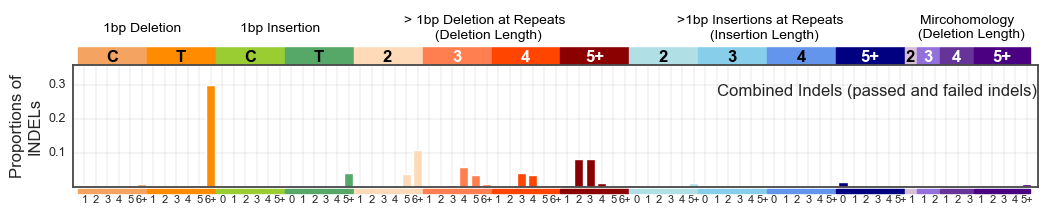

In [115]:
ID83_plot(df_combined_MSI_norm.mean()[96:], norm = True, name = 'Combined Indels (passed and failed indels)', 
          file = "./Figures/MILO_SFig19e.pdf")